# 🧭 Aplicação estratégica: as perguntas de negócio

Este notebook usa o modelo construído no [desenv_04](desenv_04_pipeline_modelagem_parte2.ipynb), que estima a probabilidade de cada rede, municipal ou estadual, cumprir a meta nacional de 2024, de 59,9% de crianças alfabetizadas, para responder às **perguntas de negócio do enunciado**, na ordem em que ele as faz. Nada é escolhido de novo aqui: o modelo é o registrado no desenv_04.

> **Convenção de trabalho:** o desenvolvimento acontece neste notebook, célula a célula, com os resultados salvos. Ao final da etapa, o código estável é promovido para `src/evaluation/prod_05_aplicacao_estrategica.py`.

**Decisões que governam este notebook** (ver [diário de decisões](../docs/decisoes.md)):
- **D-013, alvo na rede:** o modelo prevê se a rede cumpre a meta de 2024, e é lido por AUC e sensibilidade;
- **D-015, o modelo da rede:** Random Forest com 14 variáveis selecionadas, mais a UF e a região como ponto de partida.

---

## Roteiro

| Seção | Pergunta do enunciado | O que responde |
|---|---|---|
| 0 | (preparação) | os dados e o modelo do desenv_04, reconstruído com a receita registrada |
| 1 | Quais fatores mais impactam a alfabetização? | as alavancas, com o ponto de partida fixo: direção, tamanho e quem mexe |
| 2 | Quais municípios apresentam maior risco educacional? | as redes com menor chance de cumprir a meta, com alunos e distância até ela |
| 3 | Quais regiões possuem padrões semelhantes? | as regiões com a mesma distribuição de probabilidade, e o perfil das redes de cada extremo |
| 4 | Como prever municípios que podem não atingir metas futuras? | o modelo, o seu desempenho e a sua limitação, e a distância até a meta de 2030 |
| 5 | Quais variáveis possuem maior influência nos modelos? | a importância de cada variável no modelo todo, incluindo o ponto de partida |

O notebook termina com uma **síntese** das cinco respostas, que alimenta o README e o vídeo executivo.

📌 **O ponto de partida e as alavancas.** Algumas variáveis do modelo dizem onde a rede estava em 2023: a taxa da própria rede, a taxa da mesma rede no estado, a participação na avaliação, a UF e a região. Elas não mudam de um ano para o outro, explicam sobretudo quem permanece onde está e não são alavancas de política. Por isso ficam **no modelo**, como ponto de partida de cada rede, e ficam **fora da análise dos fatores** (seção 1). A pergunta 5 é o lugar delas.

🎓 **Como o modelo é lido.** Por dois prismas: a **AUC**, que mede se ele ordena bem as redes sem depender de um limiar, e a **sensibilidade**, que mede, das redes que não cumprem a meta, quantas ele encontra. A acurácia não é usada: a meta fica praticamente em cima da média do país, e um erro pequeno perto dela troca o lado da classificação, de modo que a acurácia passaria a medir sorte, e não qualidade (D-013).

## 0. Os dados e o modelo

**Passos desta seção:** (0.1) configurar o acesso ao data lake; (0.2) carregar a base e a lista de variáveis; (0.3) montar a base das redes; (0.4) reconstruir o pipeline; (0.5) reconstruir o modelo do desenv_04.

As células 0.1 a 0.4 repetem o desenv_04 sem alteração, para que este notebook rode sozinho.

📌 **O mesmo modelo, e não um parecido.** A 0.5 reconstrói o modelo com a receita registrada em `reports/modelo_rede_escolhido.json`, a família, os hiperparâmetros, as variáveis e a semente, treinado com as redes do treino e da validação, como no desenv_04. Uma trava confere que a AUC no teste é a mesma registrada lá: se não for, a célula para com erro.

In [1]:
# --- 0.1 Configuração e acesso ao data lake ---
import io
import json
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydata_google_auth
from google.cloud import storage

warnings.filterwarnings("ignore")
# os processos auxiliares do joblib não herdam o filtro acima; a variável
# de ambiente vale também para eles
os.environ["PYTHONWARNINGS"] = "ignore"
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 170)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})

CFG = json.loads(Path("../config/config.json").read_text(encoding="utf-8"))
PROJETO_GCP = CFG["projeto_gcp"]
BUCKET_LAKE = CFG["bucket_lake"]

ESCOPOS = ["https://www.googleapis.com/auth/cloud-platform"]
credenciais = pydata_google_auth.get_user_credentials(ESCOPOS)
credenciais = credenciais.with_quota_project(PROJETO_GCP)
cliente_storage = storage.Client(project=PROJETO_GCP, credentials=credenciais)


def ler_lake(area: str, tabela: str) -> pd.DataFrame:
    """Lê a partição mais recente de uma tabela do lake, a partir da memória."""
    particoes = sorted({
        b.name.split("/")[2]
        for b in cliente_storage.list_blobs(BUCKET_LAKE, prefix=f"{area}/{tabela}/")
        if len(b.name.split("/")) > 2
    })
    if not particoes:
        raise FileNotFoundError(
            f"Tabela '{tabela}' não encontrada em {area}/. "
            "Execute antes o notebook desenv_01_base_analitica.")
    caminho = f"{area}/{tabela}/{particoes[-1]}/{tabela}.parquet"
    blob = cliente_storage.bucket(BUCKET_LAKE).blob(caminho)
    print(f"  lendo {caminho}")
    return pd.read_parquet(io.BytesIO(blob.download_as_bytes()))


print(f"Lake: gs://{BUCKET_LAKE}/")
print("Setup ok")

Lake: gs://tech-challenge-fase2-lake-rm373453/
Setup ok


In [2]:
# --- 0.2 Carregar a base e a lista de variáveis ---
abt = ler_lake("ml", "abt_alfabetizacao")
lista = pd.read_csv("../reports/variaveis_modelagem.csv", index_col="variavel")
registro = json.loads(Path("../reports/modelo_rede_escolhido.json").read_text(encoding="utf-8"))
DICIONARIO = pd.read_csv("../reports/dicionario_dados.csv", index_col="variavel")

entram = lista[lista["situacao"] == "entra"]
CATEGORICAS = entram.index[entram["tipo"] == "categórica"].tolist()
NUMERICAS = entram.index[entram["tipo"] == "numérica"].tolist()
VARIAVEIS = NUMERICAS + CATEGORICAS
# UF e região ficam fora da seleção de variáveis da seção 2 e entram no modelo final,
# na seção 3, como ponto de partida, a exemplo da inércia (D-015).
TERRITORIO = ["sigla_uf", "nome_regiao"]
VARIAVEIS_MODELO = [v for v in VARIAVEIS if v not in TERRITORIO]
faltam = [v for v in VARIAVEIS + ["peso_aluno"] if v not in abt.columns]
if faltam:
    raise RuntimeError(f"Colunas ausentes na base: {faltam}")

privada = abt["rede_nome"] == "Privada"   # fora da modelagem (D-011)
abt = abt.loc[~privada, ["particao", "id_municipio", "alvo", "peso_aluno"] + VARIAVEIS].copy()
print(f"Variáveis na tabela: {len(VARIAVEIS)}   ·   no modelo: {len(VARIAVEIS_MODELO)}   ·   "
      f"rede privada retirada: {int(privada.sum())} alunos")

  lendo ml/abt_alfabetizacao/data_processamento=2026-09-14/abt_alfabetizacao.parquet
Variáveis na tabela: 43   ·   no modelo: 41   ·   rede privada retirada: 24 alunos


In [3]:
# --- 0.3 Uma linha por rede em cada município ---
META_2024, META_2030 = 59.9, 80.0   # metas nacionais pactuadas, rede pública
MIN_ALUNOS_ESTAVEL = 20             # abaixo disso, a taxa da rede oscila por tamanho de amostra
CHAVE = ["particao", "id_municipio", "rede_nome"]

# Trava: dentro de cada rede, nenhuma variável pode variar entre os alunos
variacao = (abt.groupby(CHAVE, observed=True)[NUMERICAS + ["sigla_uf", "nome_regiao"]]
            .nunique(dropna=False).max())
if (variacao > 1).any():
    raise RuntimeError(f"Variáveis que variam dentro da rede: {variacao[variacao > 1].to_dict()}")

abt["peso_alfabetizados"] = abt["peso_aluno"] * abt["alvo"]
redes = (abt.groupby(CHAVE, observed=True)
         .agg(alunos=("alvo", "size"), alfabetizados=("alvo", "sum"),
              peso_total=("peso_aluno", "sum"),
              peso_alfabetizados=("peso_alfabetizados", "sum"),
              **{v: (v, "first") for v in NUMERICAS + ["sigla_uf", "nome_regiao"]})
         .reset_index())
redes["taxa_real"] = 100 * redes["peso_alfabetizados"] / redes["peso_total"]
redes["bateu_meta"] = (redes["taxa_real"] >= META_2024).astype(int)
if redes["alunos"].sum() != len(abt):
    raise RuntimeError("A base das redes não soma os alunos da base.")


def separar_redes(particoes: list):
    """Variáveis, resposta, alunos e município das redes das partições pedidas."""
    d = redes[redes["particao"].isin(particoes)]
    return d[VARIAVEIS], d["bateu_meta"], d["alunos"], d["id_municipio"]


Xr_treino, yr_treino, alunos_treino, municipio_treino = separar_redes(["treino"])
Xr_validacao, yr_validacao, alunos_validacao, _ = separar_redes(["validacao"])
Xr_final, yr_final, alunos_final, _ = separar_redes(["treino", "validacao"])
Xr_teste, yr_teste, alunos_teste, municipio_teste = separar_redes(["teste"])

resumo = (redes.groupby("particao")
          .agg(redes=("bateu_meta", "size"), bateram_pct=("bateu_meta", "mean"),
               alunos=("alunos", "sum"),
               pequenas_pct=("alunos", lambda s: (s < MIN_ALUNOS_ESTAVEL).mean()))
          .reindex(["treino", "validacao", "teste"]))
resumo[["bateram_pct", "pequenas_pct"]] = (100 * resumo[["bateram_pct", "pequenas_pct"]]).round(1)
print(f"REDES POR PARTIÇÃO (meta de {META_2024}%; pequenas = menos de {MIN_ALUNOS_ESTAVEL} alunos)")
print(resumo.to_string())

REDES POR PARTIÇÃO (meta de 59.9%; pequenas = menos de 20 alunos)
           redes  bateram_pct   alunos  pequenas_pct
particao                                            
treino      3893         57.3  1156013           7.6
validacao   1312         56.6   384021           8.9
teste       1330         57.0   311794           8.5


In [4]:
# --- 0.4 Pipeline: definições da seção 1.4 do desenv_04, sem alteração ---
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


class PreparadorAusencias(BaseEstimator, TransformerMixin):
    """Cria os indicadores de ausência e imputa pela mediana da UF.

    As medianas são aprendidas no fit, só com os dados de treino, e
    aplicadas no transform. A UF sem valor para uma variável recebe a
    mediana nacional.
    """

    def __init__(self, numericas: list, indicadores: dict, coluna_uf: str = "sigla_uf"):
        self.numericas = numericas
        self.indicadores = indicadores
        self.coluna_uf = coluna_uf

    def fit(self, X, y=None):
        valores = X[self.numericas].astype("float64")
        self.medianas_uf_ = valores.groupby(X[self.coluna_uf]).median()
        self.medianas_nacionais_ = valores.median()
        return self

    def transform(self, X):
        X = X.copy()
        # os indicadores vêm antes da imputação, que apaga o sinal da ausência
        for nome, variavel in self.indicadores.items():
            X[nome] = X[variavel].isna().astype("int64")
        valores = X[self.numericas].astype("float64")
        da_uf = self.medianas_uf_.reindex(X[self.coluna_uf]).set_index(X.index)
        X[self.numericas] = valores.fillna(da_uf).fillna(self.medianas_nacionais_)
        return X


# O que a lista da análise exploratória determina
INDICADORES = {nome: variavel for variavel, nome
               in entram["indicador_ausencia"].dropna().items()}
COM_LOG = entram.index[entram["transformacao"].notna()].tolist()


def montar_preprocessamento(linear: bool, variaveis: list | None = None) -> Pipeline:
    """Pré-processamento completo; linear=True acrescenta logaritmo e padronização.

    variaveis restringe o pré-processamento a um subconjunto da lista, o que a
    seção 4 usa para comparar blocos de hipótese; por padrão, usa todas.
    """
    usar = set(variaveis or VARIAVEIS)
    numericas = [v for v in NUMERICAS if v in usar]
    categoricas = [v for v in CATEGORICAS if v in usar]
    indicadores = {n: v for n, v in INDICADORES.items() if v in usar}
    com_log = [v for v in COM_LOG if v in usar]
    sem_log = [v for v in numericas if v not in com_log] + list(indicadores)
    if linear:
        passos = [("log", Pipeline([
                      ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                      ("escala", StandardScaler())]), com_log),
                  ("numericas", StandardScaler(), sem_log)]
    else:
        passos = [("numericas", "passthrough", com_log + sem_log)]
    passos.append(("categoricas",
                   OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                   categoricas))
    colunas = ColumnTransformer(passos, verbose_feature_names_out=False)
    colunas.set_output(transform="pandas")
    return Pipeline([("ausencias", PreparadorAusencias(numericas, indicadores)),
                     ("colunas", colunas)])


print(f"Indicadores de ausência: {', '.join(f'{n} ({v})' for n, v in INDICADORES.items())}")
print(f"Logaritmo, só no linear: {', '.join(COM_LOG)}")
print(f"One-hot: {', '.join(CATEGORICAS)}")


def montar_modelo(estimador, linear: bool, variaveis: list | None = None) -> Pipeline:
    """Pré-processamento e modelo num único pipeline."""
    return Pipeline([("preparo", montar_preprocessamento(linear, variaveis)),
                     ("modelo", estimador)])


from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score


def medir(y, p, w=None) -> dict:
    """AUC, log-loss e Brier; sem pesos, cada rede pesa igual."""
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return {"auc": roc_auc_score(y, p, sample_weight=w),
            "log_loss": log_loss(y, p, sample_weight=w),
            "brier": brier_score_loss(y, p, sample_weight=w)}

Indicadores de ausência: sem_rede_ant (rede_taxa_ant), sem_municipio_ant (rede_vs_municipio), sem_microdados_ant (mun_participacao_ant), sem_meta (mun_gap_meta)
Logaritmo, só no linear: esc_pct_area_diferenciada, mun_pib_per_capita, mun_populacao, mun_densidade_demografica, mun_pct_vulner_deslocamento_1h
One-hot: rede_nome, sigla_uf, nome_regiao


In [5]:
# --- 0.5 O modelo do desenv_04, reconstruído com a receita registrada ---
from sklearn.ensemble import RandomForestClassifier

# o aviso do joblib repete a cada previsão da floresta e polui a saída
warnings.filterwarnings("ignore", category=UserWarning)

SEMENTE = registro["semente"]
VARIAVEIS_FINAIS = registro["variaveis"]
if registro["familia"] != "random forest":
    raise RuntimeError("O desenv_04 escolheu outra família; revise esta célula.")
modelo = montar_modelo(RandomForestClassifier(random_state=SEMENTE, n_jobs=-1, **registro["parametros"]),
                       False, VARIAVEIS_FINAIS)
modelo.fit(Xr_final, yr_final)
prob_teste = modelo.predict_proba(Xr_teste)[:, 1]

# Trava: a AUC no teste é a mesma registrada no desenv_04, então o modelo é o mesmo
auc_registrada = pd.read_csv("../reports/avaliacao_teste_rede.csv", index_col=0).loc["modelo final", "auc"]
auc_aqui = roc_auc_score(yr_teste, prob_teste)
if abs(auc_aqui - auc_registrada) > 1e-4:
    raise RuntimeError(f"O modelo não reproduz o desenv_04: AUC {auc_aqui:.5f} contra {auc_registrada:.5f}.")

# O ponto de partida: fica no modelo e fora da análise dos fatores
PONTO_DE_PARTIDA = ["rede_taxa_ant", "uf_rede_taxa_ant", "mun_participacao_ant", "sigla_uf", "nome_regiao"]
FATORES_ANALISADOS = [v for v in VARIAVEIS_FINAIS if v not in PONTO_DE_PARTIDA]
print(f"Modelo: Random Forest, {registro['parametros']}")
print(f"{len(VARIAVEIS_FINAIS)} variáveis, treinado com {len(yr_final):,} redes")
print(f"AUC no teste: {auc_aqui:.4f}, a mesma do desenv_04")
print(f"Ponto de partida ({len(PONTO_DE_PARTIDA)}): {', '.join(PONTO_DE_PARTIDA)}")
print(f"Fatores analisados ({len(FATORES_ANALISADOS)}): {', '.join(FATORES_ANALISADOS)}")

Modelo: Random Forest, {'n_estimators': 400, 'min_samples_leaf': 5, 'max_features': 0.3, 'max_depth': 12}
16 variáveis, treinado com 5,205 redes
AUC no teste: 0.8856, a mesma do desenv_04
Ponto de partida (5): rede_taxa_ant, uf_rede_taxa_ant, mun_participacao_ant, sigla_uf, nome_regiao
Fatores analisados (11): mun_populacao, mun_pct_maes_adolescentes, esc_inse_medio, esc_horas_aula_diarias, mun_densidade_demografica, esc_pct_biblioteca_ou_sala_leitura, mun_idade_mediana, mun_indice_pre_escola, esc_pct_quadra, mun_pct_vulner_deslocamento_1h, esc_pct_docentes_alto_esforco


## 1. Quais fatores mais impactam a alfabetização?

**Passos desta seção:** (1.1) retomar o que o modelo acerta, e o que isso significa para a análise; (1.2) medir cada fator com o ponto de partida fixo.

📌 **Onde está o interesse do decisor.** O modelo prevê bem quem continua onde estava, porque a taxa de 2023 já diz isso. O que importa para quem decide é o que muda: a rede que vira e passa a cumprir a meta, e a rede que cai. A 1.1 retoma esse padrão com a matriz de confusão do desenv_04 e com o acerto em cada trajetória.

**A consequência para a análise dos fatores.** As variáveis que dizem onde a rede estava, a taxa da própria rede em 2023, a taxa da mesma rede no estado, a participação na avaliação, a UF e a região, não são alavancas: ninguém muda a taxa do ano passado nem o estado em que a rede fica. Elas ficam **fixas** na 1.2, e a lupa vai para o que diferencia duas redes que partiram do mesmo lugar.

In [10]:
# --- 1.1 O que o modelo acerta: permanência e mudança ---
from IPython.display import HTML, display
from sklearn.linear_model import LogisticRegression


def numero(x: float, casas: int = 2) -> str:
    """Número no formato brasileiro, sem zeros sobrando à direita."""
    t = f"{x:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return t.rstrip("0").rstrip(",") if "," in t else t


# cores semitransparentes: as tabelas ficam legíveis no tema claro e no escuro
ESTILO = ("border:1px solid rgba(128,128,128,0.35);padding:6px 8px;vertical-align:top;text-align:left;"
          "color:inherit;background:transparent;white-space:normal;overflow-wrap:anywhere")
CABECALHO = "background:rgba(31,78,121,0.30);font-weight:600"


def tabela_html(cabecalho: list, linhas: list, larguras: list) -> str:
    """Tabela HTML na largura da tela, com o texto quebrando dentro das células."""
    html = ["<div style='overflow-x:auto;width:100%'>",
            "<table style='border-collapse:collapse;font-size:12px;color:inherit;width:100%;table-layout:fixed'>",
            "<colgroup>" + "".join(f"<col style='width:{l}%'>" for l in larguras) + "</colgroup>",
            "<tr>" + "".join(f"<th style='{ESTILO};{CABECALHO}'>{c}</th>" for c in cabecalho) + "</tr>"]
    html += ["<tr>" + "".join(f"<td style='{ESTILO}'>{x}</td>" for x in linha) + "</tr>" for linha in linhas]
    return "\n".join(html + ["</table></div>"])


redes_teste = redes[redes["particao"] == "teste"].copy()
redes_teste["p_modelo"] = prob_teste
previu_cumprir = redes_teste["p_modelo"] >= 0.5
cumpriu = redes_teste["bateu_meta"] == 1

# 1. A matriz de confusão do desenv_04, retomada
display(HTML(tabela_html(
    ["", "o modelo previu: cumpre a meta", "o modelo previu: não cumpre"],
    [["<b>aconteceu: cumpriu a meta</b>", f"{(cumpriu & previu_cumprir).sum():,}".replace(",", ".") + " redes",
      f"{(cumpriu & ~previu_cumprir).sum():,}".replace(",", ".") + " redes"],
     ["<b>aconteceu: não cumpriu a meta</b>", f"{(~cumpriu & previu_cumprir).sum():,}".replace(",", ".") + " redes",
      f"{(~cumpriu & ~previu_cumprir).sum():,}".replace(",", ".") + " redes"]],
    [34, 33, 33])))
print(f"Partição de teste: {len(redes_teste):,} redes de municípios que nenhuma etapa viu.".replace(",", "."))

# 2. O acerto em cada trajetória de 2023 para 2024, com a mesma régua de 59,9% nos dois anos
ABAIXO, NA_META = "abaixo da meta", "na meta ou acima"
situacao_2023 = np.where(redes_teste["rede_taxa_ant"].isna(), "",
                         np.where(redes_teste["rede_taxa_ant"] >= META_2024, NA_META, ABAIXO))
TRAJETORIAS = {(ABAIXO, 0): "permaneceu abaixo", (NA_META, 1): "permaneceu acima",
               (ABAIXO, 1): "virou para cima", (NA_META, 0): "caiu"}
redes_teste["trajetoria"] = [TRAJETORIAS.get((s, b), "sem resultado em 2023")
                             for s, b in zip(situacao_2023, redes_teste["bateu_meta"])]
POR_TIPO = {"permanência: a rede continuou onde estava": ["permaneceu abaixo", "permaneceu acima"],
            "mudança: a rede trocou de lado": ["virou para cima", "caiu"]}
acerto = lambda d: 100 * ((d["p_modelo"] >= 0.5) == (d["bateu_meta"] == 1)).mean()
linhas = []
for tipo, trajetorias in POR_TIPO.items():
    d = redes_teste[redes_teste["trajetoria"].isin(trajetorias)]
    linhas.append([f"<b>{tipo}</b>", f"{len(d):,}".replace(",", "."), f"<b>{numero(acerto(d), 0)}%</b>",
                   " e ".join(f"{t}: {numero(acerto(redes_teste[redes_teste['trajetoria'] == t]), 0)}%"
                              for t in trajetorias)])
display(HTML(tabela_html(["Tipo de trajetória", "Redes no teste", "O modelo acertou", "Por trajetória"],
                         linhas, [34, 14, 16, 36])))
print("Acertou: previu a situação que a rede de fato teve em 2024. A situação de 2023 usa a mesma régua de 59,9%;")
print("as redes sem resultado em 2023 ficam fora desta tabela.")

,o modelo previu: cumpre a meta,o modelo previu: não cumpre
aconteceu: cumpriu a meta,622 redes,136 redes
aconteceu: não cumpriu a meta,136 redes,436 redes


Partição de teste: 1.330 redes de municípios que nenhuma etapa viu.


Tipo de trajetória,Redes no teste,O modelo acertou,Por trajetória
permanência: a rede continuou onde estava,920,91%,permaneceu abaixo: 88% e permaneceu acima: 93%
mudança: a rede trocou de lado,385,54%,virou para cima: 58% e caiu: 48%


Acertou: previu a situação que a rede de fato teve em 2024. A situação de 2023 usa a mesma régua de 59,9%;
as redes sem resultado em 2023 ficam fora desta tabela.


**Leitura da 1.1.**

**O modelo acerta quem fica, e erra mais quem muda.** Nas redes que continuaram onde estavam, ele acerta nove em cada dez. Nas que trocaram de lado, pouco mais da metade. Na matriz, os dois tipos de erro têm o mesmo tamanho, 136 redes cada: o modelo não é otimista nem pessimista, ele erra igualmente dos dois lados.

**É um limite esperado, e não um defeito escondido.** A informação mais forte que existe na base é a taxa do ano anterior, e ela descreve a permanência. O que faz uma rede mudar de lado acontece dentro do ano, na gestão e na política local, e a base não registra isso.

📌 **Por isso a lupa vai para o que muda.** A permanência já é conhecida sem modelo. O valor está em reconhecer as redes que estão em posição de virar ou de cair, e em entender o que as distingue. É o que a 1.2 faz, mantendo o ponto de partida fixo e medindo o que diferencia duas redes que estavam no mesmo lugar.

### 1.2 Os fatores, com o ponto de partida fixo

**O que esta tabela mede.** Para cada fator, quanto a chance de uma rede cumprir a meta muda quando o fator vai de um valor baixo para um valor alto, **com o ponto de partida fixo**: entre redes que estavam no mesmo lugar em 2023, no mesmo estado, o que as separa. Os fatores analisados são as variáveis do modelo que não são ponto de partida.

**Por que medir pelo modelo, e não direto contra a resposta.** Comparar redes com mais e com menos de um fator, ou testar a diferença com um p-valor, mistura o fator com tudo o que vem junto dele: redes com mais biblioteca também têm famílias de renda maior e mais pré-escola. E o p-valor só diz que a diferença não é zero, não o tamanho dela. O modelo troca o valor de um fator mantendo todas as outras condições de cada rede como estão, e mede quanto a chance prevista se move.

🎓 **Conceito, dependência parcial.** Para um fator, o valor dele é trocado em todas as redes, primeiro para um valor baixo e depois para um valor alto, e a chance média prevista é recalculada nas duas situações. A diferença é o efeito do fator, com o resto de cada rede igual ao real. Os valores baixo e alto são os percentis 25 e 75, a faixa onde está metade das redes.

**Como ler a tabela:**

- **quem mexe:** a secretaria de educação sozinha; a educação articulada com outra pasta, que aparece embaixo do nome do fator (saúde, segurança pública, assistência social e renda, mobilidade e transporte, planejamento urbano); ou ninguém, quando o fator é uma característica do lugar (condição do território);
- **faixa típica:** os valores baixo e alto usados na conta;
- **diferença na chance:** pontos de probabilidade de cumprir a meta entre o valor baixo e o alto, entre redes parecidas no resto;
- **associado a menor chance quando:** se a chance é menor com o valor baixo ou com o valor alto;
- **esperado:** a direção esperada antes de rodar, com o motivo, e se o resultado confere;
- **regiões:** em quantas das cinco regiões o efeito aponta para o mesmo lado.

**Hipóteses, antes de rodar:**

1. os efeitos vão ser pequenos, de poucos pontos: com o ponto de partida fixo, boa parte do que as condições da rede explicam já está na taxa de 2023;
2. entre as alavancas da educação, a oferta de pré-escola e as horas-aula devem aparecer com efeito positivo, porque aumentam o contato da criança com a leitura antes e durante a escola;
3. entre as condições de fora da escola, mães adolescentes devem pesar contra e o nível socioeconômico das famílias a favor, como na análise exploratória.

⚠️ **Não é o ganho esperado de uma intervenção.** É a diferença entre redes que já existem e são parecidas no resto. Parte dela pode vir de gestão e de política local, que a base não mede. O uso certo é saber onde olhar primeiro.

In [9]:
# --- 1.2 Os fatores, com o ponto de partida fixo ---
from IPython.display import HTML, display
from sklearn.inspection import partial_dependence

# Quem mexe, a direção esperada antes de rodar (+ mais é melhor, - mais é pior, ? sem expectativa) e o motivo
QUEM_MEXE = {"educação": "A educação decide",
             "outra pasta": "A educação articula com outra pasta",
             "território": "Condição do território, não é alavanca"}
FATORES = {   # nome, quem mexe, direção esperada, motivo, pasta parceira (quando a educação articula com outra)
    "mun_indice_pre_escola": ("Oferta de pré-escola", "educação", "+", "quem passou pela pré-escola chega ao 1º ano familiarizado com letras e sons", ""),
    "esc_horas_aula_diarias": ("Horas-aula por dia", "educação", "+", "mais tempo de aula dá mais contato com a leitura", ""),
    "esc_pct_biblioteca_ou_sala_leitura": ("Escolas com biblioteca", "educação", "+", "dá acesso a livros fora da sala de aula", ""),
    "esc_pct_quadra": ("Escolas com quadra", "educação", "+", "indica escola com estrutura completa", ""),
    "esc_pct_docentes_alto_esforco": ("Professores sobrecarregados", "educação", "-", "sobra menos tempo para cada turma", ""),
    "mun_pct_maes_adolescentes": ("Mães adolescentes", "outra pasta", "-", "mãe adolescente tem, em média, menos escolaridade e menos apoio", "saúde e assistência social"),
    "esc_inse_medio": ("Nível socioeconômico das famílias", "outra pasta", "+", "famílias com mais escolaridade e renda apoiam mais a leitura; é alavanca de prazo longo, porque a política de renda muda a família antes de mudar o indicador", "assistência social e renda"),
    "mun_pct_vulner_deslocamento_1h": ("Pobres com mais de 1 hora de deslocamento", "outra pasta", "-", "longos deslocamentos cansam a família; o dado é de 2010 e aponta o problema, mas está velho para medir a situação atual", "mobilidade e transporte"),
    "mun_densidade_demografica": ("Densidade demográfica", "outra pasta", "+", "com a população concentrada, a escola fica mais perto; a densidade não muda, mas a distância que ela representa se trata com a localização das escolas e o transporte", "planejamento urbano e transporte"),
    "mun_populacao": ("População do município", "território", "?", "porte pode trazer estrutura ou complexidade", ""),
    "mun_idade_mediana": ("Idade mediana da população", "outra pasta", "+", "população mais jovem indica fecundidade alta, com mais crianças por família e gravidez precoce, e expectativa de vida menor, por mortes violentas e problemas de saúde", "saúde e segurança pública"),
}
faltam = [v for v in FATORES_ANALISADOS if v not in FATORES]
if faltam:
    raise RuntimeError(f"Fatores do modelo sem descrição: {faltam}")


def numero(x: float, casas: int = 2) -> str:
    """Número no formato brasileiro, sem zeros sobrando à direita."""
    t = f"{x:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return t.rstrip("0").rstrip(",") if "," in t else t


def efeito(dados: pd.DataFrame, variavel: str, baixo: float, alto: float) -> float:
    """Pontos de probabilidade entre o valor baixo e o alto do fator, com o resto de cada rede como está."""
    X = dados[VARIAVEIS].copy()
    X[NUMERICAS] = X[NUMERICAS].astype("float64")
    r = partial_dependence(modelo, X, [variavel], grid_resolution=21, kind="average",
                           response_method="predict_proba")
    return 100 * float(np.diff(np.interp([baixo, alto], r["grid_values"][0], r["average"][0]))[0])


amostra = redes.sample(2000, random_state=SEMENTE)
REGIOES = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
linhas = []
for v in FATORES_ANALISADOS:
    baixo, alto = redes[v].quantile([.25, .75])
    valor = efeito(amostra, v, baixo, alto)
    regioes = sum(np.sign(efeito(redes[redes["nome_regiao"] == r], v, baixo, alto)) == np.sign(valor)
                  for r in REGIOES)
    nome, quem, sinal, motivo, pasta = FATORES[v]
    linhas.append({"variavel": v, "nome": nome, "quem": quem, "sinal": sinal, "motivo": motivo, "pasta": pasta,
                   "baixo": baixo, "alto": alto, "efeito_pp": valor, "regioes": regioes})
fatores = pd.DataFrame(linhas).set_index("variavel")
fatores["ordem"] = fatores["quem"].map({"educação": 0, "outra pasta": 1, "território": 2})
fatores = fatores.assign(absoluto=fatores["efeito_pp"].abs()).sort_values(["ordem", "absoluto"],
                                                                        ascending=[True, False])

# cores semitransparentes: a tabela fica legível no tema claro e no escuro
ESTILO = ("border:1px solid rgba(128,128,128,0.35);padding:6px 8px;vertical-align:top;text-align:left;"
          "color:inherit;background:transparent;white-space:normal;overflow-wrap:anywhere")
# largura de cada coluna, em %: a tabela ocupa a largura da tela e o texto quebra dentro da célula
LARGURAS = [11, 3, 12, 19, 9, 8, 9, 23, 6]
cabecalho = ["Quem mexe", "#", "Fator", "O que mede", "Faixa típica", "Diferença na chance",
             "Associado a menor chance quando", "Esperado", "Regiões"]
html = ["<div style='overflow-x:auto;width:100%'>",
        "<table style='border-collapse:collapse;font-size:12px;color:inherit;width:100%;table-layout:fixed'>",
        "<colgroup>" + "".join(f"<col style='width:{l}%'>" for l in LARGURAS) + "</colgroup>",
        "<tr>" + "".join(f"<th style='{ESTILO};background:rgba(31,78,121,0.30);font-weight:600'>{c}</th>"
                         for c in cabecalho) + "</tr>"]
numero_linha = 0
for quem, titulo in QUEM_MEXE.items():
    grupo = fatores[fatores["quem"] == quem]
    for k, (v, f) in enumerate(grupo.iterrows()):
        numero_linha += 1
        obtido = "+" if f["efeito_pp"] >= 0 else "-"
        if f["sinal"] == "?":
            esperado = f"sem expectativa: {f['motivo']}"
        else:
            confere = "confere" if f["sinal"] == obtido else "<b>não confere: não é recomendação</b>"
            esperado = f"{'mais é melhor' if f['sinal'] == '+' else 'mais é pior'}, porque {f['motivo']} ({confere})"
        celula_grupo = (f"<td rowspan='{len(grupo)}' style='{ESTILO};background:rgba(31,78,121,0.14)'><b>{titulo}</b></td>"
                        if k == 0 else "")
        html.append(
            "<tr>" + celula_grupo
            + f"<td style='{ESTILO}'>{numero_linha}</td><td style='{ESTILO}'><b>{f['nome']}</b>"
            + (f"<br><i>com {f['pasta']}</i>" if f['pasta'] else "") + "</td>"
            + f"<td style='{ESTILO}'>{DICIONARIO.loc[v, 'descricao']} ({DICIONARIO.loc[v, 'unidade']})</td>"
            + f"<td style='{ESTILO}'>de {numero(f['baixo'])} a {numero(f['alto'])}</td>"
            + f"<td style='{ESTILO}'>{'+' if f['efeito_pp'] >= 0 else '−'}{numero(abs(f['efeito_pp']), 1)} pontos</td>"
            + f"<td style='{ESTILO}'>{'valor baixo' if f['efeito_pp'] >= 0 else 'valor alto'}</td>"
            + f"<td style='{ESTILO}'>{esperado}</td><td style='{ESTILO}'>{int(f['regioes'])} de 5</td></tr>")
html.append("</table></div>")
display(HTML("\n".join(html)))
fatores.drop(columns=["ordem", "absoluto"]).round(4).to_csv("../reports/fatores_meta_2024.csv", encoding="utf-8")
print("Diferença na chance: pontos de probabilidade de cumprir a meta entre o percentil 25 e o 75 do fator,")
print("com o ponto de partida e as demais condições de cada rede como estão. Tabela em reports/fatores_meta_2024.csv")

Diferença na chance: pontos de probabilidade de cumprir a meta entre o percentil 25 e o 75 do fator,
com o ponto de partida e as demais condições de cada rede como estão. Tabela em reports/fatores_meta_2024.csv


**Leitura.**

**A resposta à pergunta 1.** Entre redes que partiram do mesmo lugar em 2023, o que mais separa as que cumprem a meta das que não cumprem está **fora da escola**: a gravidez na adolescência, o nível socioeconômico das famílias, a estrutura etária da população e as longas distâncias até o trabalho. Dentro da escola, as alavancas mais fortes são a **oferta de pré-escola** e a **biblioteca**.

**Os efeitos são pequenos, como esperado (hipótese 1).** Nenhum fator passa de 3,5 pontos de probabilidade. Isso não quer dizer que as condições da rede importem pouco para a alfabetização: quer dizer que o efeito delas já está, em boa parte, na taxa de 2023. O que a tabela da 1.2 mostra é o que ainda diferencia duas redes que estavam no mesmo lugar e no mesmo estado.

**O que a educação decide.** A pré-escola é a alavanca mais forte do grupo: uma rede de município com oferta alta de pré-escola tem 1,4 ponto a mais de chance do que uma parecida com oferta baixa, e o sinal se mantém nas cinco regiões. A biblioteca vem depois (0,9). Horas-aula e quadra aparecem na direção esperada, mas com efeito pequeno, e professores sobrecarregados pesam contra. A hipótese 2 se confirma para a pré-escola, e só em parte para as horas-aula.

**O que depende de outra pasta.** É aqui que estão os maiores efeitos: mães adolescentes pesam contra (3,3 pontos), e o nível socioeconômico das famílias (2,3), a idade mediana da população (1,7) e o deslocamento curto (1,5) pesam a favor. A hipótese 3 se confirma. Para o decisor, a mensagem é que a alfabetização se decide também na atenção básica, na assistência social, na segurança pública e no transporte, e não só dentro da escola.

**A condição do território.** Com o resto igual, redes de municípios maiores têm 3,5 pontos a menos de chance. É uma característica do lugar, e não uma alavanca, mas indica que as redes grandes e urbanas enfrentam dificuldades que as outras variáveis não capturam.

**Todas as direções conferem com o esperado.** Nenhum fator aparece com o sinal contrário ao previsto, e quase todos mantêm a direção nas cinco regiões. Com as 41 variáveis antigas, quatro fatores contrariavam o esperado; a curadoria do desenv_04 tirou as variáveis que confundiam a leitura.

📌 **Consequência para as próximas perguntas.** Os fatores com pasta parceira e as alavancas da educação são a base da seção 3, que agrupa as redes pelo gargalo que mais pesa em cada uma.

## 2. Quais municípios apresentam maior risco educacional?

🎓 **O que é uma "rede" aqui.** É a **rede de um município**: o conjunto de escolas da rede municipal, ou da rede estadual, dentro de um mesmo município. Não é a rede municipal ou a estadual do país inteiro. A rede municipal de Sorocaba e a rede estadual em Sorocaba são duas unidades diferentes, cada uma com a sua taxa e a sua previsão. São 6.535 dessas redes, em 5.570 municípios.

**A resposta desta seção** é a lista das redes que o modelo aponta como "não vai cumprir a meta" **e que de fato não cumpriram**, ordenadas pelo número de alunos. São os acertos do modelo: os casos em que ele teria avisado antes, e o aviso se confirmou. A ordenação por alunos coloca no topo onde há mais crianças envolvidas.

📌 **O tamanho do problema, em pontos da taxa nacional.** Cada rede da lista traz também quanto a taxa de alfabetização do país subiria se ela chegasse exatamente à meta, e o acumulado dessa conta linha a linha. A última linha mostra o total: onde o país chegaria se todas as redes apontadas cumprissem a meta. É a forma de comparar o peso de cada rede sem depender do tamanho absoluto dela.

⚠️ **A ressalva da previsão.** O modelo foi treinado com 80% dos municípios, e a previsão é honesta só nas redes da partição de **teste**. Nas demais, ele já tinha visto a resposta no treino, e o acerto é mais fácil. A partição aparece na lista e no arquivo gravado.

In [19]:
# --- 2.1 As redes de maior risco, entre as que o modelo acertou ---
redes["p_cumprir"] = modelo.predict_proba(redes[VARIAVEIS])[:, 1]
redes["risco"] = 100 * (1 - redes["p_cumprir"])
apontadas = redes["p_cumprir"] < 0.5          # o modelo previu que a rede não cumpre a meta
nao_cumpriu = redes["bateu_meta"] == 0        # e de fato não cumpriu
acertos = redes[apontadas & nao_cumpriu].copy()

# A taxa nacional é a mesma conta da taxa oficial: alunos alfabetizados sobre o total, com o peso do INEP
peso_nacional = redes["peso_total"].sum()
taxa_nacional = 100 * redes["peso_alfabetizados"].sum() / peso_nacional
# Se a rede chegasse exatamente à meta, quantos alunos alfabetizados a mais ela teria, e quanto isso move o país
acertos["ganho_pp"] = (100 * (META_2024 / 100 * acertos["peso_total"] - acertos["peso_alfabetizados"])
                       / peso_nacional)

milhar = lambda v: f"{int(v):,}".replace(",", ".")
print(f"Redes apontadas pelo modelo: {milhar(apontadas.sum())} de {milhar(len(redes))}; dessas, não cumpriram "
      f"a meta: {milhar(len(acertos))} ({100 * len(acertos) / apontadas.sum():.0f}%), com "
      f"{milhar(acertos['alunos'].sum())} alunos.")
print(f"Taxa nacional de alfabetização em 2024: {numero(taxa_nacional, 1)}%, contra a meta de {numero(META_2024, 1)}%.")
print()

diretorio = ler_lake("bronze", "diretorio_municipio")[["id_municipio", "nome"]]
# ordenadas pelo impacto: quanto cada rede move a taxa nacional se chegar à meta
lista = acertos.merge(diretorio, on="id_municipio", how="left").sort_values("ganho_pp", ascending=False)
QUANTAS = 15
if lista["nome"].isna().any():
    raise RuntimeError("Há município sem nome no diretório.")
lista["ganho_acumulado"] = lista["ganho_pp"].cumsum()
lista["taxa_nacional_se_cumprissem"] = taxa_nacional + lista["ganho_acumulado"]

linhas = [[f"<b>{l['nome']}</b>", l["sigla_uf"], l["rede_nome"], f"{l['alunos']:,}".replace(",", "."),
           numero(l["taxa_real"], 1) + "%", numero(META_2024 - l["taxa_real"], 1) + " pp",
           numero(l["risco"], 0) + "%", "+" + numero(l["ganho_pp"], 3) + " pp",
           numero(l["taxa_nacional_se_cumprissem"], 2) + "%"]
          for _, l in lista.head(QUANTAS).iterrows()]
topo = lista.head(QUANTAS)
linhas.append([f"<b>total das {QUANTAS} primeiras</b>", "", "",
               f"<b>{topo['alunos'].sum():,}</b>".replace(",", "."), "", "", "",
               "<b>+" + numero(topo["ganho_pp"].sum(), 2) + " pp</b>",
               "<b>" + numero(taxa_nacional + topo["ganho_pp"].sum(), 2) + "%</b>"])
display(HTML(tabela_html(
    ["Município", "UF", "Rede", "Alunos", "Taxa de 2024", "Falta para a meta", "Risco apontado",
     "Ganho na taxa nacional", "Taxa nacional acumulada"],
    linhas, [17, 4, 9, 9, 10, 11, 9, 15, 16])))
lista[["id_municipio", "nome", "sigla_uf", "rede_nome", "alunos", "taxa_real", "risco", "ganho_pp",
       "ganho_acumulado", "particao"]].to_csv("../reports/redes_risco_2024.csv", index=False, encoding="utf-8")

ganho_total = lista["ganho_pp"].sum()
metade = int((lista["ganho_pp"].cumsum() < ganho_total / 2).sum() + 1)
print(f"Ganho na taxa nacional: quanto a taxa do país subiria se aquela rede chegasse exatamente à meta de "
      f"{numero(META_2024, 1)}%, mantendo todas as outras como estão. A coluna seguinte acumula esse ganho.")
print(f"Para referência: se todas as {milhar(len(lista))} redes da lista chegassem à meta, a taxa nacional "
      f"iria a {numero(taxa_nacional + ganho_total, 2)}%.")
print(f"As {QUANTAS} primeiras respondem por {100 * topo['ganho_pp'].sum() / ganho_total:.0f}% desse ganho e por "
      f"{100 * topo['alunos'].sum() / lista['alunos'].sum():.0f}% dos alunos da lista; metade do ganho está nas "
      f"{milhar(metade)} primeiras redes.")
print(f"As {milhar(len(lista))} redes da lista, com a partição de cada uma, em reports/redes_risco_2024.csv")


Redes apontadas pelo modelo: 2.709 de 6.535; dessas, não cumpriram a meta: 2.380 (88%), com 820.614 alunos.
Taxa nacional de alfabetização em 2024: 59,2%, contra a meta de 59,9%.

  lendo bronze/diretorio_municipio/data_ingestao=2026-07-11/diretorio_municipio.parquet


Município,UF,Rede,Alunos,Taxa de 2024,Falta para a meta,Risco apontado,Ganho na taxa nacional,Taxa nacional acumulada
São Paulo,SP,Municipal,41.751,"48,3%","11,6 pp",87%,"+0,271 pp","59,47%"
Salvador,BA,Municipal,12.112,"36,7%","23,2 pp",96%,"+0,133 pp","59,6%"
Manaus,AM,Municipal,18.666,"50,1%","9,8 pp",95%,"+0,114 pp","59,72%"
Nova Iguaçu,RJ,Municipal,6.380,"33,4%","26,5 pp",93%,"+0,098 pp","59,82%"
Guarulhos,SP,Municipal,9.951,"44,2%","15,7 pp",89%,"+0,089 pp","59,9%"
Porto Alegre,RS,Estadual,4.904,"31,5%","28,4 pp",97%,"+0,088 pp","59,99%"
Porto Alegre,RS,Municipal,2.485,"20,5%","39,4 pp",93%,"+0,07 pp","60,06%"
Duque de Caxias,RJ,Municipal,6.581,"45,4%","14,5 pp",96%,"+0,057 pp","60,12%"
Maceió,AL,Municipal,5.283,"40,9%",19 pp,97%,"+0,052 pp","60,17%"
Natal,RN,Municipal,2.780,"33,4%","26,5 pp",98%,"+0,051 pp","60,22%"


Ganho na taxa nacional: quanto a taxa do país subiria se aquela rede chegasse exatamente à meta de 59,9%, mantendo todas as outras como estão. A coluna seguinte acumula esse ganho.
Para referência: se todas as 2.380 redes da lista chegassem à meta, a taxa nacional iria a 65,49%.
As 15 primeiras respondem por 20% desse ganho e por 16% dos alunos da lista; metade do ganho está nas 134 primeiras redes.
As 2.380 redes da lista, com a partição de cada uma, em reports/redes_risco_2024.csv


**Leitura da seção 2.**

**A resposta.** O modelo aponta 2.709 redes como prováveis não cumpridoras da meta, e 2.380 delas de fato não cumpriram, reunindo 820 mil alunos. São essas as redes de maior risco educacional, e a tabela as ordena pelo quanto cada uma pesa no resultado do país.

**Poucas redes movem o país.** Se apenas as 15 primeiras chegassem à meta, a taxa nacional sairia de 59,2% para 60,45%: o país passaria da meta de 2024 com quinze redes. São Paulo sozinha vale 0,27 ponto.

**Mas o problema é espalhado.** Essas 15 respondem por só 20% de todo o ganho possível da lista e por 16% dos alunos dela. Metade do ganho exige chegar a 134 redes, e o restante está espalhado por mais de 2.200. Um plano restrito às capitais não resolve.

**Quem está na frente da fila.** As primeiras são redes municipais de capitais e de regiões metropolitanas, como São Paulo, Salvador, Manaus, a Baixada Fluminense e Porto Alegre, com taxas entre 20% e 50%. É coerente com a seção 1: com o resto igual, redes de municípios maiores vão pior.

**O teto do esforço.** Se todas as 2.380 redes chegassem à meta, a taxa nacional iria a 65,5%, bem acima dos 59,9% de 2024 e já dentro da trajetória rumo a 2030.

⚠️ **Duas ressalvas.** A previsão é honesta só nas redes da partição de teste; nas demais o modelo já tinha visto a resposta, e o acerto é mais fácil. E a lista é retrospectiva: mostra onde o modelo teria avisado antes de sair o resultado de 2024, e não uma previsão para os anos seguintes.

## 3. Quais regiões possuem padrões semelhantes?

O modelo dá a cada rede uma probabilidade de cumprir a meta, de 0 a 100%. Dentro de uma região, essas probabilidades formam uma distribuição: algumas regiões têm quase todas as redes amontoadas perto de zero, outras espalhadas, outras concentradas perto de 100%. **Duas regiões se parecem quando essas distribuições têm o mesmo formato.**

**Passos desta seção:** (3.1) desenhar a distribuição de cada região e medir a semelhança entre elas.

🎓 **Como a semelhança é medida.** A faixa de 0 a 100% é dividida em dez pedaços de dez pontos. Para cada região, calcula-se a fração das redes em cada pedaço, o que dá a silhueta da distribuição. A semelhança entre duas regiões é a **sobreposição** dessas silhuetas: pedaço a pedaço, toma-se o menor valor entre as duas e somam-se os resultados. Uma sobreposição de 100% significa distribuições idênticas, e 0% significa que não compartilham nenhuma rede na mesma faixa.

**Por que isso responde a pergunta.** A distribuição resume, num único retrato, o que o modelo enxerga de cada região: o nível das redes, o quanto elas variam entre si e se há dois mundos dentro da mesma região. Regiões com o mesmo retrato pedem o mesmo tipo de política.

⚠️ **Sobre a leitura.** A probabilidade vem do modelo e depende sobretudo do ponto de partida de cada rede, o que inclui a taxa da UF em 2023. A semelhança medida aqui é, portanto, de **situação**, e não de causa: duas regiões podem ter a mesma silhueta por motivos diferentes, o que a seção 1 ajuda a separar.

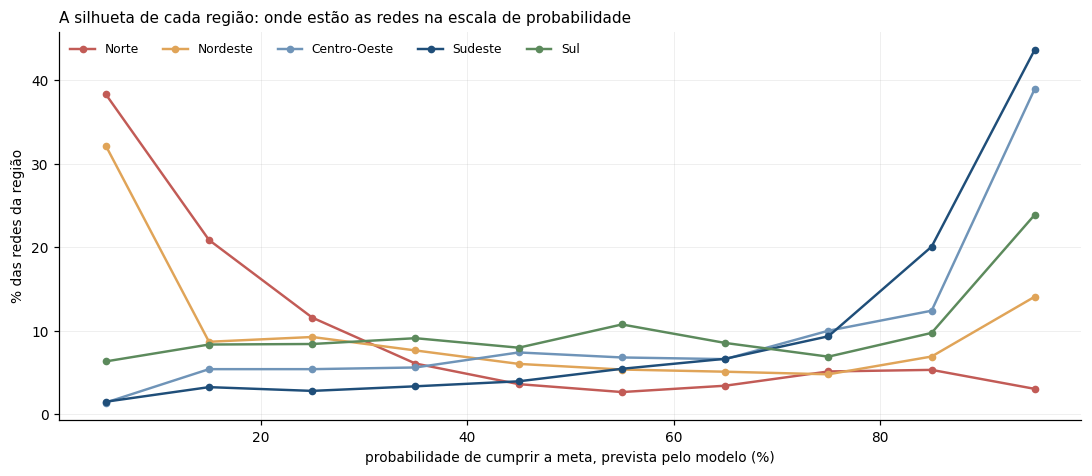

Região,Redes,Alunos,Taxa mediana de 2024,Probabilidade mediana,até 25%,25 a 50%,50 a 75%,acima de 75%
Norte,527,188.095,"50,5%",14%,66%,15%,9%,11%
Nordeste,1.924,465.488,"52,2%",30%,46%,18%,13%,23%
Centro-Oeste,500,175.205,"71,4%",81%,9%,16%,18%,56%
Sudeste,2.003,744.637,"71,9%",88%,6%,9%,16%,69%
Sul,1.581,278.403,"63,4%",60%,19%,21%,23%,37%


Sobreposição entre as regiões,Norte,Nordeste,Centro-Oeste,Sudeste,Sul
Norte,,79%,41%,34%,52%
Nordeste,79%,,60%,51%,73%
Centro-Oeste,41%,60%,,88%,79%
Sudeste,34%,51%,88%,,67%
Sul,52%,73%,79%,67%,


Pares mais parecidos: Centro-Oeste e Sudeste (88%); Centro-Oeste e Sul (79%); Norte e Nordeste (79%)
Pares mais diferentes: Nordeste e Sudeste (51%); Norte e Centro-Oeste (41%); Norte e Sudeste (34%)

Sobreposição: somando faixa a faixa a menor das duas frações. 100% seria a mesma distribuição.


In [25]:
# --- 3.1 A silhueta de cada região e a semelhança entre elas ---
REGIOES = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
PEDACOS = np.arange(0, 101, 10)
CORES = {"Norte": "#c25b56", "Nordeste": "#e0a458", "Centro-Oeste": "#6f94b8",
         "Sudeste": "#1f4e79", "Sul": "#5c8a5c"}

redes["p_cumprir_pct"] = 100 * redes["p_cumprir"]
silhuetas = {}
for regiao in REGIOES:
    d = redes[redes["nome_regiao"] == regiao]
    contagem, _ = np.histogram(d["p_cumprir_pct"], bins=PEDACOS)
    silhuetas[regiao] = contagem / contagem.sum()
silhuetas = pd.DataFrame(silhuetas, index=[f"{a} a {b}%" for a, b in zip(PEDACOS[:-1], PEDACOS[1:])])

fig, eixo = plt.subplots(figsize=(10, 4.4))
centros = PEDACOS[:-1] + 5
for regiao in REGIOES:
    eixo.plot(centros, 100 * silhuetas[regiao], "o-", ms=4, lw=1.6, color=CORES[regiao], label=regiao)
eixo.set_xlabel("probabilidade de cumprir a meta, prevista pelo modelo (%)")
eixo.set_ylabel("% das redes da região")
eixo.set_title("A silhueta de cada região: onde estão as redes na escala de probabilidade",
               fontsize=10, loc="left")
eixo.legend(fontsize=8, frameon=False, ncol=5)
eixo.grid(alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

# O retrato de cada região, em números
FAIXAS = [0, 25, 50, 75, 100]
linhas = []
for regiao in REGIOES:
    d = redes[redes["nome_regiao"] == regiao]
    partes = pd.cut(d["p_cumprir_pct"], FAIXAS, include_lowest=True).value_counts(normalize=True).sort_index()
    linhas.append([f"<b>{regiao}</b>", milhar(len(d)), milhar(d["alunos"].sum()),
                   numero(d["taxa_real"].median(), 1) + "%",
                   numero(d["p_cumprir_pct"].median(), 0) + "%"]
                  + [numero(100 * v, 0) + "%" for v in partes])
display(HTML(tabela_html(
    ["Região", "Redes", "Alunos", "Taxa mediana de 2024", "Probabilidade mediana",
     "até 25%", "25 a 50%", "50 a 75%", "acima de 75%"],
    linhas, [13, 9, 12, 13, 13, 10, 10, 10, 10])))

# A semelhança: sobreposição das silhuetas, par a par
sobreposicao = pd.DataFrame(
    [[100 * np.minimum(silhuetas[a], silhuetas[b]).sum() for b in REGIOES] for a in REGIOES],
    index=REGIOES, columns=REGIOES)
display(HTML(tabela_html(
    ["Sobreposição entre as regiões"] + REGIOES,
    [[f"<b>{a}</b>"] + [("" if a == b else numero(sobreposicao.loc[a, b], 0) + "%") for b in REGIOES]
     for a in REGIOES],
    [20] + [16] * 5)))

pares = [(a, b, sobreposicao.loc[a, b]) for i, a in enumerate(REGIOES) for b in REGIOES[i + 1:]]
pares.sort(key=lambda x: x[2], reverse=True)
print("Pares mais parecidos: " + "; ".join(f"{a} e {b} ({numero(v, 0)}%)" for a, b, v in pares[:3]))
print("Pares mais diferentes: " + "; ".join(f"{a} e {b} ({numero(v, 0)}%)" for a, b, v in pares[-3:]))
print()
print("Sobreposição: somando faixa a faixa a menor das duas frações. 100% seria a mesma distribuição.")

### 3.2 O que as redes de cada foco têm em comum

A 3.1 mostrou que as regiões se juntam em dois blocos opostos. Esta célula compara os dois extremos fator a fator, para dizer **como são as redes de cada um**. O Sul fica de fora: suas redes não se concentram em nenhuma ponta, e a região não forma par com nenhuma outra.

| foco | quem entra |
|---|---|
| **baixo** | redes do Norte e do Nordeste com até 25% de chance de cumprir a meta |
| **alto** | redes do Centro-Oeste e do Sudeste com mais de 75% de chance |

**Duas formas de medir a diferença entre eles, lado a lado:**

- **a diferença crua,** na unidade da própria variável: por exemplo, quantos pontos percentuais de mães adolescentes separam um foco do outro. É a leitura concreta;
- **a diferença em desvios padrão,** que divide a diferença crua pelo espalhamento daquela variável entre todas as redes do país. Serve para comparar variáveis de unidades diferentes: uma diferença de 1 desvio é grande em qualquer variável, e uma de 0,2 é pequena, mesmo que o número cru pareça alto.

A tabela é ordenada pela segunda, então os fatores que mais separam os dois mundos ficam no topo. É retrato, e não causa.

In [24]:
# --- 3.2 O que as redes de cada foco têm em comum ---
FOCOS = {
    "Foco baixo<br><i>Norte e Nordeste,<br>até 25% de chance</i>":
        redes["nome_regiao"].isin(["Norte", "Nordeste"]) & (redes["p_cumprir_pct"] <= 25),
    "Foco alto<br><i>Centro-Oeste e Sudeste,<br>acima de 75%</i>":
        redes["nome_regiao"].isin(["Centro-Oeste", "Sudeste"]) & (redes["p_cumprir_pct"] > 75),
}

resumo = [[f"<b>{nome}</b>", milhar(filtro.sum()), milhar(redes.loc[filtro, "alunos"].sum()),
           numero(redes.loc[filtro, "taxa_real"].median(), 1) + "%",
           numero(100 * (1 - redes.loc[filtro, "bateu_meta"].mean()), 0) + "%"]
          for nome, filtro in FOCOS.items()]
display(HTML(tabela_html(["Foco", "Redes", "Alunos", "Taxa mediana de 2024", "Não cumpriram a meta"],
                         resumo, [34, 14, 18, 18, 16])))

baixo, alto = list(FOCOS)
medianas = pd.DataFrame({nome: redes.loc[filtro, FATORES_ANALISADOS].median() for nome, filtro in FOCOS.items()})
medianas["país"] = redes[FATORES_ANALISADOS].median()
diferenca = medianas[alto] - medianas[baixo]                       # na unidade da variável
em_desvios = diferenca / redes[FATORES_ANALISADOS].std()           # comparável entre variáveis
ordem = em_desvios.abs().sort_values(ascending=False).index

def fmt(x: float) -> str:
    """Duas casas nos fatores em escala pequena, nenhuma em população e densidade."""
    return numero(x, 0) if abs(x) >= 1000 else numero(x, 2)


linhas = []
for v in ordem:
    nome, quem, _, _, pasta = FATORES[v]
    grupo = {"educação": "a educação decide", "outra pasta": f"com {pasta}",
             "território": "condição do território"}[quem]
    linhas.append([f"<b>{nome}</b><br><i>{grupo}</i>", DICIONARIO.loc[v, "descricao"],
                   DICIONARIO.loc[v, "unidade"], fmt(medianas.loc[v, baixo]),
                   fmt(medianas.loc[v, alto]), fmt(medianas.loc[v, "país"]),
                   ("+" if diferenca[v] >= 0 else "−") + fmt(abs(diferenca[v])),
                   ("+" if em_desvios[v] >= 0 else "−") + numero(abs(em_desvios[v]), 2)])
display(HTML(tabela_html(
    ["Fator", "O que mede", "Unidade", "Foco baixo", "Foco alto", "País",
     "Diferença (alto menos baixo)", "Diferença em desvios padrão"],
    linhas, [17, 22, 11, 9, 9, 8, 12, 12])))
print("Diferença (alto menos baixo): na unidade da própria variável. Positiva quer dizer que o foco alto tem mais.")
print("Diferença em desvios padrão: a mesma diferença dividida pelo espalhamento da variável entre todas as redes")
print("do país. Acima de 1 desvio, os dois focos quase não se sobrepõem naquela variável; abaixo de 0,2, a")
print("diferença é pequena diante da variação normal entre redes.")

Foco,Redes,Alunos,Taxa mediana de 2024,Não cumpriram a meta
"Foco baixoNorte e Nordeste,até 25% de chance",1.222,379.413,"39,6%",97%
"Foco altoCentro-Oeste e Sudeste,acima de 75%",1.660,364.123,"77,5%",3%


Fator,O que mede,Unidade,Foco baixo,Foco alto,País,Diferença (alto menos baixo),Diferença em desvios padrão
Nível socioeconômico das famíliascom assistência social e renda,nível socioeconômico médio das famílias atendidas pela rede,"escala do INEP, valores entre 3,4 e 6,1 na base","4,42","5,06","4,91","+0,64","+1,33"
Mães adolescentescom saúde e assistência social,nascidos vivos de mãe com menos de 20 anos,"% dos nascidos vivos, de 0 a 100","24,4",16,"18,5","−8,4","−1,29"
Escolas com bibliotecaa educação decide,escolas com biblioteca ou sala de leitura,"% de escolas, de 0 a 100","28,5","66,7",50,"+38,2","+1,23"
Idade mediana da populaçãocom saúde e segurança pública,idade mediana da população,anos,32,37,36,+5,"+1,12"
Escolas com quadraa educação decide,escolas com quadra de esportes,"% de escolas, de 0 a 100","14,3","43,35","33,3","+29,05","+1,06"
Pobres com mais de 1 hora de deslocamentocom mobilidade e transporte,"pessoas pobres que gastam mais de uma hora até o trabalho, aproximação das distâncias no território","% de pessoas, de 0 a 100","1,84","0,65","0,86","−1,19","−0,77"
Oferta de pré-escolaa educação decide,"oferta de pré-escola diante dos anos iniciais, todas as redes do município","índice, 1 indica equilíbrio","0,86","0,93","0,91","+0,07","+0,54"
Professores sobrecarregadosa educação decide,professores dos anos iniciais nos dois níveis mais altos de esforço,"% de professores, de 0 a 100","1,2",4,"3,4","+2,8","+0,43"
População do municípiocondição do território,população do município,habitantes,17.863,10.880,12.810,−6.983,"−0,02"
Densidade demográficacom planejamento urbano e transporte,habitantes por quilômetro quadrado,habitantes por km²,"26,05","25,25","25,2","−0,8",−0


Diferença (alto menos baixo): na unidade da própria variável. Positiva quer dizer que o foco alto tem mais.
Diferença em desvios padrão: a mesma diferença dividida pelo espalhamento da variável entre todas as redes
do país. Acima de 1 desvio, os dois focos quase não se sobrepõem naquela variável; abaixo de 0,2, a
diferença é pequena diante da variação normal entre redes.


**Leitura da seção 3.**

**A resposta: quais regiões se parecem.** Duas duplas, e só duas. A semelhança aqui é entre as **regiões inteiras**, com todas as suas redes, e não entre um pedaço delas. **Norte e Nordeste** formam uma dupla, com 79% de sobreposição entre as silhuetas. **Centro-Oeste e Sudeste** formam o outro, com 88%. O Sul não entra na resposta porque não forma par com ninguém: suas redes ficam espalhadas pelas quatro faixas de probabilidade (19% / 21% / 23% / 37%), sem concentração em nenhuma ponta. As duas duplas são opostas entre si: Norte e Sudeste sobrepõem 34%, o menor valor da matriz.

**A 3.2 muda a escala, de propósito.** Para descrever o perfil, ela não usa as regiões inteiras: recorta a **ponta** de cada dupla, que é onde cada uma concentra suas redes. De um lado, as redes do Norte e do Nordeste com até 25% de chance; do outro, as do Centro-Oeste e do Sudeste acima de 75%. São os dois extremos do país postos frente a frente, e é por isso que as distâncias saem maiores do que sairiam comparando região com região.

| ponta | quem entra | redes | alunos | taxa mediana de 2024 | fora da meta |
|---|---|---|---|---|---|
| **baixa** | Norte e Nordeste, até 25% de chance | 1.222 | 379 mil | 39,6% | 97% |
| **alta** | Centro-Oeste e Sudeste, acima de 75% | 1.660 | 364 mil | 77,5% | 3% |

Quase o mesmo número de crianças nos dois lados, separadas por 38 pontos de alfabetização.

**O que faz as regiões de uma dupla se parecerem.** Não é a geografia, é o perfil das redes. As redes da ponta baixa compartilham um retrato: famílias com nível socioeconômico de 4,42 numa escala que vai a 6,1, quase um quarto dos nascimentos de mães com menos de 20 anos, menos de um terço das escolas com biblioteca, uma em cada sete com quadra, população jovem (idade mediana de 32 anos) e a maior parcela de pobres com mais de uma hora de deslocamento. As redes da ponta alta compartilham o retrato espelhado. É isso que o modelo enxerga quando dá a duas regiões a mesma silhueta: as redes de uma se parecem com as da outra mais do que com as da região do outro lado.

**O que distingue uma ponta da outra: os mesmos fatores, em graus diferentes.** Nenhum fator existe numa ponta e falta na outra. Todos estão presentes nas duas, em posições distintas da mesma régua:

| fator | ponta baixa | ponta alta | distância |
|---|---|---|---|
| Nível socioeconômico das famílias | 4,42 | 5,06 | 1,33 desvios |
| Mães adolescentes | 24,4% | 16,0% | 1,29 desvios |
| Escolas com biblioteca | 28,5% | 66,7% | 1,23 desvios |
| Idade mediana da população | 32 anos | 37 anos | 1,12 desvios |
| Escolas com quadra | 14,3% | 43,4% | 1,06 desvios |
| Pobres com mais de 1 hora de deslocamento | 1,84% | 0,65% | 0,77 desvio |
| Oferta de pré-escola | 0,86 | 0,93 | 0,54 desvio |

Cinco fatores passam de um desvio, e é aí que mora a diferença entre os dois mundos. Três deles a educação só move junto com outra pasta (renda, saúde e assistência social) e dois ela decide sozinha, mas são infraestrutura acumulada, que leva anos de obra e compra. Nenhum é botão de um ano, o que explica por que a diferença entre as pontas é estável e não se resolve com uma campanha.

**O que as duas pontas têm em comum.** Horas-aula por dia é 4,5 nas duas, diferença zero. Densidade demográfica empata. E a população mediana tem 6.983 habitantes de diferença, o que parece muito, mas vira 0,02 desvio, porque a população varia de mil a milhões entre as redes. Esses três são régua nacional: valem igual no país inteiro e, por isso mesmo, não explicam a distância entre as pontas, ainda que a jornada tenha efeito dentro do modelo (1.2).

**O Nordeste carrega dois mundos dentro dele.** É a única região com peso nas duas pontas: 46% das redes até 25% de chance e 23% acima de 75%. A média regional esconde essa divisão, e uma política nordestina única erraria os dois lados.

**Um sinal invertido, e a lição dele.** Professores sobrecarregados aparece maior na ponta alta (4,0% contra 1,2%), o contrário do que a 1.2 mediu entre redes parecidas (−0,7 ponto). Não é contradição: comparar dois mundos inteiros não é comparar redes semelhantes. Redes maiores e mais formalizadas do Centro-Oeste e do Sudeste concentram professores com carga cheia, enquanto redes pequenas do Norte e do Nordeste quase não têm docentes nesses níveis. A direção de política vem da 1.2, que segura tudo o mais igual; a 3.2 diz com quem conversar, e não para que lado empurrar.

**O que isso quer dizer para a decisão.** Como as duas pontas diferem em grau e não em natureza, a lista de alavancas é a mesma, e o que muda é a intensidade e o prazo. A ponta baixa pede pacote combinado, educação com saúde, assistência social e renda, mais investimento em espaço escolar, com prazo de anos. A ponta alta pede ajuste fino, porque já está do outro lado da meta. O que não funciona é aplicar a mesma dose nos dois.

⚠️ **Limite.** A probabilidade vem do modelo, que tem UF e região no ponto de partida, então parte da semelhança entre regiões vizinhas é construída pelo próprio território dentro do modelo. O perfil foi lido nas pontas, com as duas regiões de cada dupla juntas: descreve o extremo de cada lado, e não a região inteira. E a tabela é retrato de como são as redes de cada ponta, não a causa de estarem ali.

## 4. Como prever municípios que podem não atingir metas futuras?

A previsão já existe: o modelo dá a cada rede uma probabilidade de cumprir a meta. O que falta é dizer **como usar esse número**, e a forma direta é a faixa em que a rede cai. Uma rede com até 25% de chance é um caso quase perdido; uma entre 25% e 50% ainda pode virar para qualquer lado. A pergunta prática é o que aconteceu de fato com as redes de cada faixa, porque disso depende o tamanho da aposta que o gestor faz em cima da previsão.

**Passos desta seção:** (4.1) ver, em cada faixa de probabilidade, quanto das redes cumpriu e quanto não cumpriu a meta; (4.2) ver no mapa onde ficam os municípios das faixas mais baixas.

🎓 **Por que a faixa, e não o carimbo.** Classificar apenas em "cumpre" e "não cumpre" joga fora a informação mais útil, que é a distância até a linha de corte. A faixa preserva essa distância e permite resposta graduada: intervenção onde a chance é pequena, acompanhamento onde ela é média.

⚠️ **Onde cada coisa é medida.** O resultado por faixa (4.1) é medido na partição de **teste**, a única em que a previsão é honesta. O mapa (4.2) precisa cobrir o país inteiro e por isso usa todas as redes, com a ressalva já declarada na seção 2: nas redes de treino o modelo já tinha visto a resposta.

Faixa de probabilidade,Redes,% das redes,Alunos,Taxa mediana de 2024,Não cumpriram a meta,Cumpriram a meta
até 25%,317,24%,117.759,42%,89%,11%
25 a 50%,255,19%,40.699,"56,1%",60%,40%
50 a 75%,231,17%,38.672,"64,2%",39%,61%
acima de 75%,527,40%,114.664,"77,5%",9%,91%


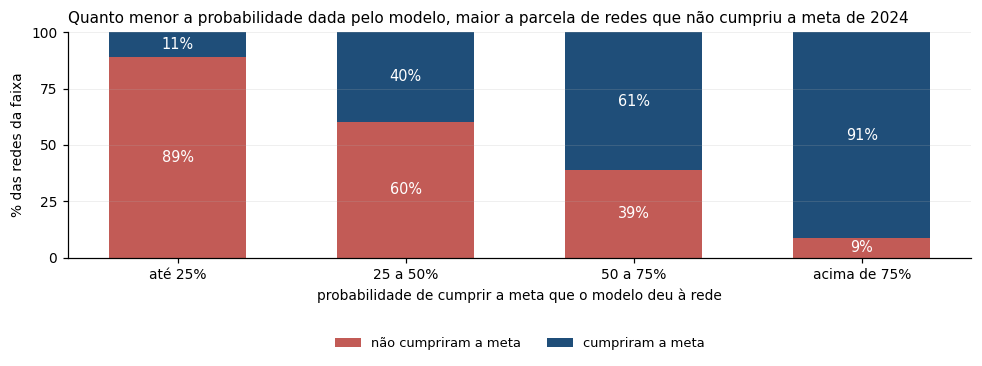

Partição de teste: 1.330 redes de municípios que nenhuma etapa viu.
Cada faixa soma 100%: as duas últimas colunas repartem as redes daquela faixa entre as que não
cumpriram e as que cumpriram a meta de 2024.


In [33]:
# --- 4.1 O resultado de 2024 em cada faixa de probabilidade do modelo ---
CORTES = [0, 25, 50, 75, 100]
ROTULOS = ["até 25%", "25 a 50%", "50 a 75%", "acima de 75%"]

redes_teste["faixa"] = pd.cut(100 * redes_teste["p_modelo"], CORTES, include_lowest=True, labels=ROTULOS)
saida = redes_teste.groupby("faixa", observed=True).agg(
    redes=("bateu_meta", "size"), cumpriram=("bateu_meta", "sum"),
    alunos=("alunos", "sum"), taxa=("taxa_real", "median")).reindex(ROTULOS)
saida["cumpriram_pct"] = 100 * saida["cumpriram"] / saida["redes"]
saida["nao_cumpriram_pct"] = 100 - saida["cumpriram_pct"]

linhas = [[f"<b>{faixa}</b>", milhar(l["redes"]), numero(100 * l["redes"] / saida["redes"].sum(), 0) + "%",
           milhar(l["alunos"]), numero(l["taxa"], 1) + "%",
           "<b>" + numero(l["nao_cumpriram_pct"], 0) + "%</b>", numero(l["cumpriram_pct"], 0) + "%"]
          for faixa, l in saida.iterrows()]
display(HTML(tabela_html(
    ["Faixa de probabilidade", "Redes", "% das redes", "Alunos", "Taxa mediana de 2024",
     "Não cumpriram a meta", "Cumpriram a meta"],
    linhas, [16, 11, 11, 12, 16, 17, 17])))

fig, eixo = plt.subplots(figsize=(9, 3.8))
nao = saida["nao_cumpriram_pct"].to_numpy()
sim = saida["cumpriram_pct"].to_numpy()
b1 = eixo.bar(ROTULOS, nao, color="#c25b56", width=.6, label="não cumpriram a meta")
b2 = eixo.bar(ROTULOS, sim, bottom=nao, color="#1f4e79", width=.6, label="cumpriram a meta")
eixo.bar_label(b1, labels=[numero(v, 0) + "%" for v in nao], label_type="center", fontsize=9.5,
               color="white")
eixo.bar_label(b2, labels=[numero(v, 0) + "%" for v in sim], label_type="center", fontsize=9.5,
               color="white")
eixo.set_ylim(0, 100)
eixo.set_yticks([0, 25, 50, 75, 100])
eixo.set_xlabel("probabilidade de cumprir a meta que o modelo deu à rede")
eixo.set_ylabel("% das redes da faixa")
eixo.set_title("Quanto menor a probabilidade dada pelo modelo, maior a parcela de redes que não "
               "cumpriu a meta de 2024", fontsize=10, loc="left")
eixo.legend(fontsize=8.5, frameon=False, ncol=2, loc="lower center", bbox_to_anchor=(.5, -.46))
eixo.grid(axis="y", alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

print(f"Partição de teste: {milhar(len(redes_teste))} redes de municípios que nenhuma etapa viu.")
print("Cada faixa soma 100%: as duas últimas colunas repartem as redes daquela faixa entre as que não")
print("cumpriram e as que cumpriram a meta de 2024.")

### 4.2 Onde ficam os municípios em alerta

O mapa leva as faixas da 4.1 para o território. Como o grão do modelo é a rede, e um município pode ter rede municipal e rede estadual, a probabilidade de cada município é a **média das suas redes, ponderada pelo número de alunos**.

São dois painéis, que empilham as faixas: o primeiro mostra apenas os municípios com **chance pequena** de atingir a meta, de até 25%; o segundo acrescenta os de **chance média**, de 25% a 50%. A comparação entre os dois mostra quanto o problema cresce quando o critério afrouxa, e onde esse crescimento acontece.

> 📌 Os contornos vêm da API de malhas territoriais do IBGE, lidos direto, sem bibliotecas geográficas, no mesmo formato usado no [desenv_02](desenv_02_analise_exploratoria.ipynb). O arquivo é guardado em `data/` na primeira execução.

Malha: 5.570 municípios, 5.598 contornos, 99% deles casados com a base


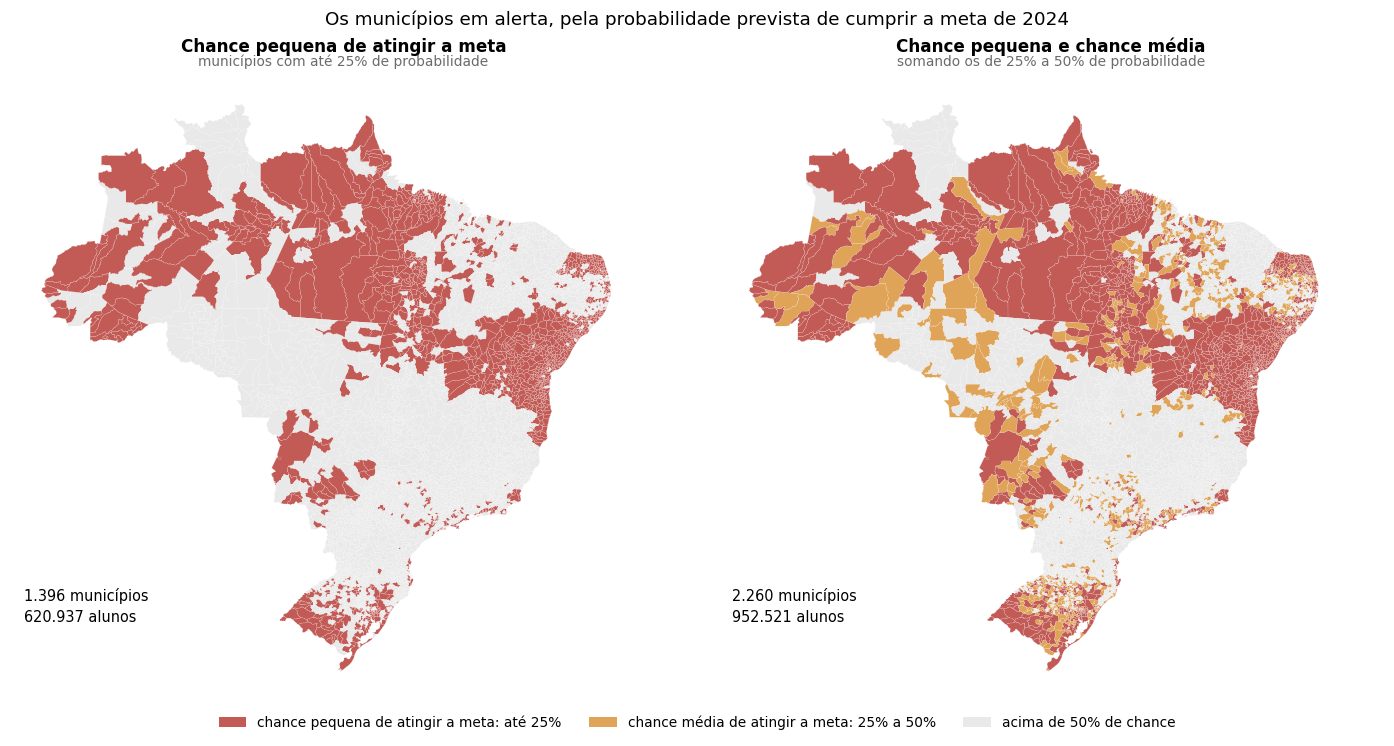

Faixa do município,Municípios,% dos municípios,Alunos,% dos alunos
até 25%,1.396,25%,620.937,34%
25 a 50%,864,16%,331.584,18%
as duas faixas juntas,2.260,41%,952.521,51%


Base do mapa: 5.517 municípios, 1.851.828 alunos, todas as redes públicas.
A probabilidade do município é a média das suas redes, ponderada pelo número de alunos.


In [34]:
# --- 4.2 Onde ficam os municípios em alerta ---
import gzip
import urllib.request

from matplotlib.collections import PolyCollection

CAMINHO_MALHA = Path("../data/malha_municipios_ibge.json")
URL_MALHA = ("https://servicodados.ibge.gov.br/api/v3/malhas/paises/BR"
             "?formato=application/vnd.geo+json&intrarregiao=municipio&qualidade=minima")


def malha_municipios() -> list:
    """Contornos dos municípios do país, com cópia guardada em data/."""
    if not CAMINHO_MALHA.exists():
        print("  baixando a malha municipal do IBGE (só na primeira vez)")
        with urllib.request.urlopen(URL_MALHA, timeout=300) as resposta:
            bruto = resposta.read()
        if bruto[:2] == b"\x1f\x8b":
            bruto = gzip.decompress(bruto)
        CAMINHO_MALHA.write_bytes(bruto)
    return json.loads(CAMINHO_MALHA.read_text(encoding="utf-8"))["features"]


def contornos(geometria: dict) -> list:
    """Contorno externo de cada polígono que compõe o município."""
    if geometria["type"] == "Polygon":
        return [np.array(geometria["coordinates"][0])]
    return [np.array(poligono[0]) for poligono in geometria["coordinates"]]


# A probabilidade do município: média das suas redes, ponderada pelos alunos
redes["p_vezes_alunos"] = redes["p_cumprir_pct"] * redes["alunos"]
municipios = redes.groupby("id_municipio").agg(soma=("p_vezes_alunos", "sum"),
                                               alunos=("alunos", "sum"), redes=("alunos", "size"))
municipios["p_cumprir_pct"] = municipios["soma"] / municipios["alunos"]
municipios.index = municipios.index.astype(str).str.replace(r"\.0$", "", regex=True)

ALERTAS = [("até 25%", municipios["p_cumprir_pct"] <= 25, "#c25b56"),
           ("25 a 50%", municipios["p_cumprir_pct"].between(25, 50, inclusive="right"), "#e0a458")]
CINZA = "#e9e9e9"
malha = malha_municipios()
poligonos, codigos = [], []
for feicao in malha:
    for anel in contornos(feicao["geometry"]):
        poligonos.append(anel)
        codigos.append(feicao["properties"]["codarea"])
codigos = pd.Series(codigos)
casaram = codigos.isin(municipios.index).mean()
if casaram < 0.5:
    raise RuntimeError(f"Só {casaram:.0%} dos contornos casaram com a base; confira o id_municipio.")
print(f"Malha: {milhar(len(malha))} municípios, {milhar(len(poligonos))} contornos, "
      f"{casaram:.0%} deles casados com a base")

PAINEIS = [("Chance pequena de atingir a meta", "municípios com até 25% de probabilidade",
            ALERTAS[:1]),
           ("Chance pequena e chance média", "somando os de 25% a 50% de probabilidade",
            ALERTAS)]
fig, eixos = plt.subplots(1, 2, figsize=(13, 7))
fig.suptitle("Os municípios em alerta, pela probabilidade prevista de cumprir a meta de 2024",
             fontsize=12, y=.965)
for eixo, (titulo, subtitulo, alertas) in zip(eixos, PAINEIS):
    cores = pd.Series(CINZA, index=codigos.index)
    total_mun, total_alunos = 0, 0
    for _, filtro, cor in alertas:
        alvo = set(municipios.index[filtro])
        cores[codigos.isin(alvo).to_numpy()] = cor
        total_mun += int(filtro.sum())
        total_alunos += int(municipios.loc[filtro, "alunos"].sum())
    eixo.add_collection(PolyCollection(poligonos, facecolors=cores.to_numpy(),
                                       edgecolors="white", linewidths=.08))
    eixo.autoscale_view()
    eixo.set_aspect("equal")
    eixo.axis("off")
    # título curto acima do mapa e subtítulo logo abaixo dele, os dois centralizados
    eixo.set_title(titulo, fontsize=11, fontweight="600", pad=16)
    eixo.text(.5, 1.012, subtitulo, transform=eixo.transAxes, ha="center", va="bottom",
              fontsize=9, color="#6b6b6b")
    # os números ficam dentro do painel, no vazio à esquerda do mapa
    eixo.text(.02, .12, f"{milhar(total_mun)} municípios\n{milhar(total_alunos)} alunos",
              transform=eixo.transAxes, ha="left", va="bottom", fontsize=9.5, linespacing=1.5)
marcas = [plt.Rectangle((0, 0), 1, 1, fc=cor) for _, _, cor in ALERTAS] + \
         [plt.Rectangle((0, 0), 1, 1, fc=CINZA)]
fig.legend(marcas, ["chance pequena de atingir a meta: até 25%",
                    "chance média de atingir a meta: 25% a 50%",
                    "acima de 50% de chance"],
           loc="lower center", ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(.5, .015))
fig.subplots_adjust(left=.01, right=.99, top=.88, bottom=.07, wspace=.02)
plt.show()

linhas = []
for rotulo, filtro, _ in ALERTAS:
    d = municipios[filtro]
    linhas.append([f"<b>{rotulo}</b>", milhar(len(d)), numero(100 * len(d) / len(municipios), 0) + "%",
                   milhar(int(d["alunos"].sum())),
                   numero(100 * d["alunos"].sum() / municipios["alunos"].sum(), 0) + "%"])
acumulado = municipios["p_cumprir_pct"] <= 50
linhas.append(["<b>as duas faixas juntas</b>", "<b>" + milhar(int(acumulado.sum())) + "</b>",
               numero(100 * acumulado.mean(), 0) + "%",
               "<b>" + milhar(int(municipios.loc[acumulado, "alunos"].sum())) + "</b>",
               numero(100 * municipios.loc[acumulado, "alunos"].sum() / municipios["alunos"].sum(), 0) + "%"])
display(HTML(tabela_html(["Faixa do município", "Municípios", "% dos municípios", "Alunos", "% dos alunos"],
                         linhas, [26, 16, 18, 20, 20])))
print(f"Base do mapa: {milhar(len(municipios))} municípios, "
      f"{milhar(int(municipios['alunos'].sum()))} alunos, todas as redes públicas.")
print("A probabilidade do município é a média das suas redes, ponderada pelo número de alunos.")

**Leitura da seção 4.**

**A resposta: a previsão se usa por faixa, e a faixa tem confiabilidade conhecida.** A 4.1 mostra que a probabilidade do modelo ordena o resultado sem falha: das redes com até 25% de chance, 89% não cumpriram a meta; na faixa de 25% a 50%, 60%; de 50% a 75%, 39%; acima de 75%, apenas 9%. Cada degrau de probabilidade corresponde a um degrau no resultado real, e é isso que permite usar o número antes de o resultado sair.

| faixa | redes no teste | não cumpriram | taxa mediana de 2024 | como usar |
|---|---|---|---|---|
| até 25% | 317 (24%) | 89% | 42,0%, a 18 pontos da meta | intervir, a previsão é firme |
| 25 a 50% | 255 (19%) | 60% | 56,1%, a 3,8 pontos da meta | acompanhar de perto, pode virar |
| 50 a 75% | 231 (17%) | 39% | 64,2%, a 4,3 pontos acima | monitorar, pode cair |
| acima de 75% | 527 (40%) | 9% | 77,5%, com folga | nenhuma ação específica |

**As pontas são firmes, o meio é indeciso.** Nas duas faixas extremas, que reúnem 64% das redes, o modelo erra cerca de uma em dez. Nas duas faixas do meio, 486 redes, o resultado fica perto do empate: a faixa de 25% a 50% termina 60 contra 40, e a de 50% a 75%, 39 contra 61. Não é defeito do modelo, é a natureza dessas redes, que terminam o ano a poucos pontos da linha. A taxa mediana explica: 56,1% e 64,2%, ambas a menos de cinco pontos dos 59,9% da meta. Ali, qualquer oscilação troca o lado.

**Por isso a resposta de política é graduada.** Onde a chance é pequena, a rede está a 18 pontos da meta e o modelo confirma nove vezes em dez: é intervenção. Onde a chance é média, metade vira: é acompanhamento, com custo menor, porque uma parte dessas redes cumpre sozinha. Tratar as duas faixas com o mesmo remédio gasta esforço onde ele não decide nada.

**No país, o alerta cobre metade das crianças.** O mapa da 4.2 leva as faixas aos 5.517 municípios com rede pública. Os de chance pequena são 1.396, ou 25% dos municípios, mas concentram 620.937 alunos, 34% do total: são municípios maiores que a média nacional. Somando os de chance média, chega-se a 2.260 municípios, 41% do país, com 952.521 alunos, **51% de todas as crianças avaliadas**. O desenho da mancha repete o que a seção 3 já tinha mostrado pela distribuição de probabilidade: ela se concentra no Norte e no Nordeste, onde 66% e 46% das redes ficam abaixo de 25% de chance.

**O que isso quer dizer para metas futuras.** O procedimento se repete a cada ciclo: com os dados do ano anterior, o modelo devolve a probabilidade de cada rede, a faixa dá a força da previsão, e a tabela da 4.1 diz quanto vale confiar em cada faixa. O que não se transporta são os números: a meta de 2030 é de 80%, bem acima dos 59,9% de 2024, então a régua muda e o modelo precisa ser treinado de novo com o alvo novo. Quem se repete é o método, não o resultado.

⚠️ **Dois limites.** O primeiro vem da 1.1: o modelo acerta 91% das redes que permanecem onde estavam e 54% das que mudam de lado, então a previsão é mais frágil justamente onde a política age. O segundo é o mapa: ele usa todas as redes para cobrir o país, e nas redes de treino o modelo já tinha visto a resposta, o que torna a mancha um pouco mais nítida do que seria numa aplicação real. Os números da 4.1, medidos só no teste, são a referência honesta.

## 5. Quais variáveis possuem maior influência nos modelos?

A seção 1 respondeu quais **fatores** mais impactam a alfabetização, e para isso manteve o ponto de partida fixo: ela perguntava o que move a chance entre redes que partiram do mesmo lugar. Esta seção faz a pergunta do modelo inteiro, com as 16 variáveis, o ponto de partida incluído. São perguntas diferentes, e as respostas também são.

**Passos desta seção:** (5.1) medir a influência de cada variável, uma a uma; (5.2) medir a influência do ponto de partida e dos fatores em bloco.

🎓 **Como a influência é medida.** Por **permutação**: embaralha-se uma variável entre as redes, o que destrói a ligação dela com o resultado sem mexer em nada mais, e mede-se quanto o desempenho piora. Quanto maior a piora, mais o modelo dependia daquela variável. É a mesma régua usada na curadoria da seção 2 do desenv_04, então os números conversam entre si. A piora aparece em duas medidas: a **log-loss**, que é sensível à probabilidade em si, e a **AUC**, que só olha a ordenação.

⚠️ **O crédito dividido.** A taxa da própria rede em 2023 e a taxa da mesma rede no estado são variáveis parentes. Quando uma é embaralhada, a outra cobre parte da informação perdida, e as duas aparecem menores do que são. Por isso a 5.2 repete a medida **em bloco**, embaralhando o ponto de partida inteiro de uma vez e depois os fatores inteiros. A pergunta que o bloco responde é a que interessa ao gestor: pesa mais de onde a rede partiu ou a condição em que ela está.

📌 **Sobre o plural do enunciado.** A medida é feita no modelo adotado, no grão da rede, que é o que sustenta as respostas das seções 1 a 4. O modelo do desenv_03, no grão do aluno, aparece só como comentário na leitura, sem somar nada: são escopos diferentes.

#,Variável,Papel no modelo,O que mede,Piora na log-loss,Piora na AUC
1,Taxa da própria rede em 2023,ponto de partida,taxa de alfabetização da rede do aluno no município,"0,1454","0,1066"
2,Unidade da federação,ponto de partida,unidade da federação,"0,0766","0,0547"
3,Taxa da mesma rede no estado em 2023,ponto de partida,benchmark: mediana da mesma rede entre os municípios da UF,"0,0611","0,0329"
4,Região,ponto de partida,região do país,"0,0151","0,0073"
5,Participação na avaliação em 2023,ponto de partida,percentual de alunos presentes na avaliação anterior,"0,0124","0,0073"
6,Nível socioeconômico das famílias,alavanca,nível socioeconômico médio das famílias atendidas pela rede,"0,0092","0,0034"
7,População do município,alavanca,população do município,"0,0087","0,0045"
8,Mães adolescentes,alavanca,nascidos vivos de mãe com menos de 20 anos,"0,0078","0,0038"
9,Densidade demográfica,alavanca,habitantes por quilômetro quadrado,"0,0043","0,0021"
10,Escolas com quadra,alavanca,escolas com quadra de esportes,"0,0041","0,0026"


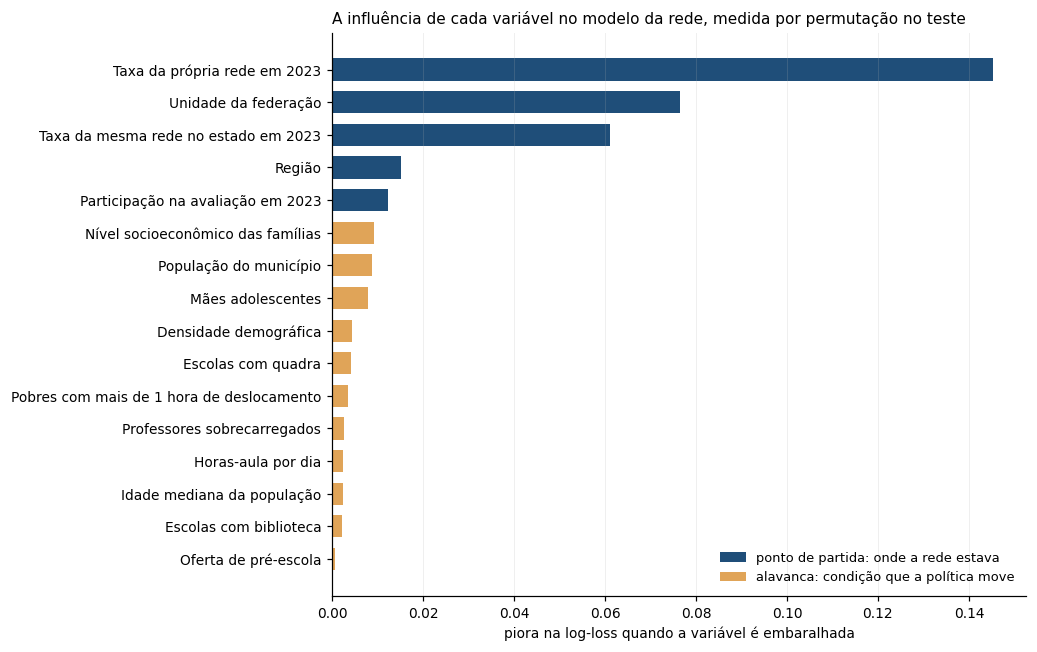

Permutação no teste, 10 embaralhamentos por variável, média das repetições.
Piora: quanto a medida se degrada quando a variável perde a ligação com o resultado.
A soma das pioras individuais não é o total: variáveis parentes dividem o crédito entre si (5.2).
Tabela gravada em reports/influencia_variaveis_rede.csv


In [36]:
# --- 5.1 A influência de cada variável, uma a uma ---
from sklearn.inspection import permutation_importance

REPETICOES = 10
NOMES = {v: FATORES[v][0] for v in FATORES_ANALISADOS}
NOMES.update({"rede_taxa_ant": "Taxa da própria rede em 2023",
              "uf_rede_taxa_ant": "Taxa da mesma rede no estado em 2023",
              "mun_participacao_ant": "Participação na avaliação em 2023",
              "sigla_uf": "Unidade da federação", "nome_regiao": "Região"})
PAPEL = {v: ("ponto de partida" if v in PONTO_DE_PARTIDA else "alavanca") for v in VARIAVEIS_FINAIS}

# só as colunas que o modelo usa; as demais continuam na base, mas ele não as enxerga
X_final_teste = Xr_teste[VARIAVEIS_FINAIS]
influencia = permutation_importance(modelo, X_final_teste, yr_teste, scoring=["neg_log_loss", "roc_auc"],
                                    n_repeats=REPETICOES, random_state=SEMENTE, n_jobs=-1)
tabela = pd.DataFrame({"piora_log_loss": influencia["neg_log_loss"].importances_mean,
                       "piora_auc": influencia["roc_auc"].importances_mean},
                      index=X_final_teste.columns).sort_values("piora_log_loss", ascending=False)
tabela["papel"] = [PAPEL[v] for v in tabela.index]

linhas = [[f"<b>{i + 1}</b>", f"<b>{NOMES[v]}</b>", PAPEL[v], DICIONARIO.loc[v, "descricao"],
           numero(l["piora_log_loss"], 4), numero(l["piora_auc"], 4)]
          for i, (v, l) in enumerate(tabela.iterrows())]
display(HTML(tabela_html(
    ["#", "Variável", "Papel no modelo", "O que mede", "Piora na log-loss", "Piora na AUC"],
    linhas, [4, 20, 13, 35, 14, 14])))

fig, eixo = plt.subplots(figsize=(9.5, 6))
ordem = tabela.sort_values("piora_log_loss")
cores = ["#1f4e79" if p == "ponto de partida" else "#e0a458" for p in ordem["papel"]]
eixo.barh([NOMES[v] for v in ordem.index], ordem["piora_log_loss"], color=cores, height=.68)
eixo.set_xlabel("piora na log-loss quando a variável é embaralhada")
eixo.set_title("A influência de cada variável no modelo da rede, medida por permutação no teste",
               fontsize=10, loc="left")
marcas = [plt.Rectangle((0, 0), 1, 1, fc="#1f4e79"), plt.Rectangle((0, 0), 1, 1, fc="#e0a458")]
eixo.legend(marcas, ["ponto de partida: onde a rede estava", "alavanca: condição que a política move"],
            fontsize=8.5, frameon=False, loc="lower right")
eixo.grid(axis="x", alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

tabela.to_csv("../reports/influencia_variaveis_rede.csv", encoding="utf-8")
print(f"Permutação no teste, {REPETICOES} embaralhamentos por variável, média das repetições.")
print("Piora: quanto a medida se degrada quando a variável perde a ligação com o resultado.")
print("A soma das pioras individuais não é o total: variáveis parentes dividem o crédito entre si (5.2).")
print("Tabela gravada em reports/influencia_variaveis_rede.csv")

### 5.2 Ponto de partida e alavancas, em bloco

Embaralhar uma variável por vez subestima grupos de variáveis parentes, porque as que ficam intactas cobrem parte da informação perdida. Esta célula embaralha **grupos inteiros de uma vez**, mantendo a relação entre as variáveis de dentro do grupo e destruindo apenas a ligação do grupo com o resultado.

São quatro medidas, todas contra o modelo completo: sem o ponto de partida inteiro, sem os onze fatores, sem apenas o território (UF e região) e sem apenas as taxas de 2023. A comparação diz de onde vem a capacidade de previsão do modelo, e quanto dela está em coisas que a política consegue mover.

In [37]:
# --- 5.2 Ponto de partida e alavancas, em bloco ---
REPETICOES_BLOCO = 10
TERRITORIO_BLOCO = ["sigla_uf", "nome_regiao"]
TAXAS_2023 = [v for v in PONTO_DE_PARTIDA if v not in TERRITORIO_BLOCO]
BLOCOS = {"sem o ponto de partida<br><i>as 5 variáveis de onde a rede estava</i>": PONTO_DE_PARTIDA,
          "sem as alavancas<br><i>os 11 fatores da seção 1</i>": FATORES_ANALISADOS,
          "sem o território<br><i>só UF e região</i>": TERRITORIO_BLOCO,
          "sem as medidas de 2023<br><i>taxa da rede, taxa na UF e participação</i>": TAXAS_2023}

gerador = np.random.default_rng(SEMENTE)
auc_cheio = roc_auc_score(yr_teste, prob_teste)
perda_cheia = log_loss(yr_teste, prob_teste)


def embaralhar_bloco(colunas: list, repeticoes: int) -> tuple:
    """AUC e log-loss médias com o bloco de colunas embaralhado entre as redes."""
    medidas = []
    for _ in range(repeticoes):
        X = Xr_teste[VARIAVEIS_FINAIS].copy()
        X[colunas] = X[colunas].to_numpy()[gerador.permutation(len(X))]
        p = modelo.predict_proba(X)[:, 1]
        medidas.append((roc_auc_score(yr_teste, p), log_loss(yr_teste, p)))
    return tuple(np.mean(medidas, axis=0))


linhas = [["<b>modelo completo</b>", str(len(VARIAVEIS_FINAIS)), numero(auc_cheio, 4),
           numero(perda_cheia, 4), "", ""]]
for nome, colunas in BLOCOS.items():
    auc, perda = embaralhar_bloco(colunas, REPETICOES_BLOCO)
    linhas.append([f"<b>{nome}</b>", str(len(colunas)), numero(auc, 4), numero(perda, 4),
                   "<b>" + numero(auc_cheio - auc, 4) + "</b>", numero(perda - perda_cheia, 4)])
display(HTML(tabela_html(
    ["Medida", "Variáveis embaralhadas", "AUC", "Log-loss", "Queda na AUC", "Piora na log-loss"],
    linhas, [30, 14, 12, 12, 16, 16])))
print(f"Cada grupo é embaralhado junto, {REPETICOES_BLOCO} vezes, com o restante do modelo intacto.")
print("Queda na AUC: quanto da capacidade de ordenar as redes vinha daquele grupo de variáveis.")

Medida,Variáveis embaralhadas,AUC,Log-loss,Queda na AUC,Piora na log-loss
modelo completo,16,"0,8856","0,4169",,
sem o ponto de partidaas 5 variáveis de onde a rede estava,5,"0,5407","0,8958","0,3449","0,4788"
sem as alavancasos 11 fatores da seção 1,11,"0,8482","0,4779","0,0375","0,061"
sem o territóriosó UF e região,2,"0,7992","0,5352","0,0865","0,1183"
"sem as medidas de 2023taxa da rede, taxa na UF e participação",3,"0,6565","0,7111","0,2291","0,2942"


Cada grupo é embaralhado junto, 10 vezes, com o restante do modelo intacto.
Queda na AUC: quanto da capacidade de ordenar as redes vinha daquele grupo de variáveis.


**Leitura da seção 5.**

**A resposta: as cinco primeiras posições são do ponto de partida.** A taxa da própria rede em 2023 lidera com folga, seguida pela UF, pela taxa da mesma rede no estado, pela região e pela participação na avaliação. Só na sexta posição aparece a primeira alavanca, o nível socioeconômico das famílias.

| # | variável | papel | piora na log-loss |
|---|---|---|---|
| 1 | Taxa da própria rede em 2023 | ponto de partida | 0,1454 |
| 2 | Unidade da federação | ponto de partida | 0,0766 |
| 3 | Taxa da mesma rede no estado em 2023 | ponto de partida | 0,0611 |
| 4 | Região | ponto de partida | 0,0151 |
| 5 | Participação na avaliação em 2023 | ponto de partida | 0,0124 |
| 6 | Nível socioeconômico das famílias | alavanca | 0,0092 |

**A distância não é de posição, é de ordem de grandeza.** Embaralhar a taxa de 2023 piora a log-loss em 0,1454, quase dezesseis vezes mais do que embaralhar a maior das alavancas. As onze alavancas somadas chegam a 0,0480, menos de um terço do que a taxa de 2023 faz sozinha.

**Em bloco, a conta fica explícita.** Sem o ponto de partida inteiro, a AUC cai de 0,8856 para **0,5407**, praticamente o mesmo que sortear a ordem das redes: o modelo perde a capacidade de ordenar. Sem as onze alavancas, ele ainda entrega 0,8482. Dentro do ponto de partida, as medidas de 2023 pesam mais (queda de 0,2291) do que o território (0,0865), mas nenhum dos dois é dispensável.

**O bloco mostra o que a medida individual esconde.** As três medidas de 2023, somadas uma a uma, valem 0,1468 de AUC; embaralhadas juntas, 0,2291. O território vai de 0,0620 para 0,0865, e as alavancas, de 0,0218 para 0,0375. É o crédito dividido que a abertura da seção antecipou: quando uma variável é embaralhada sozinha, a parente que ficou intacta cobre parte do buraco, e as duas parecem menores do que são.

**E é isto que explica a limitação da 1.1.** Se as variáveis de maior peso são as que permanecem iguais de 2023 para 2024, o modelo chega com boa parte da decisão tomada antes de olhar qualquer condição da rede: ele aposta, por construção, na continuidade. Daí vem o acerto de 91% nas redes que permaneceram onde estavam e de apenas 54% nas que trocaram de lado. A limitação não é um defeito solto que apareceu na avaliação, é a consequência direta desta tabela de influências: um modelo apoiado na inércia acerta a inércia.

**Influência no modelo não é utilidade para a política, e esta é a leitura que importa.** O que mais influencia a previsão é exatamente o que ninguém consegue mudar de um ano para o outro: onde a rede estava e em que estado ela fica. As alavancas influenciam pouco a previsão porque explicam o que sobra depois que o ponto de partida já explicou quase tudo, e é justamente esse resto que a política consegue mover. A seção 1 mediu o tamanho desse resto com o ponto de partida fixo: de 0,4 a 3,5 pontos de probabilidade entre redes que partiram do mesmo lugar. São duas perguntas diferentes, e as duas precisam ser respondidas.

**A seção confirma as duas metades da D-015.** Manter o território e a inércia dentro do modelo se justifica porque, sem eles, a previsão desaba para o nível do acaso. Mantê-los fora da análise de alavancas também se justifica, porque a influência deles é toda inércia: prevê bem e não se move. A 5.2 mede as duas coisas na mesma tabela.

**No grão do aluno, a mesma história por outro caminho.** No desenv_03, repetir a taxa de 2023 já alcançava AUC de 0,643, contra 0,673 do modelo completo: quase toda a ordenação vinha da inércia também ali. A diferença é que no grão da rede o ruído individual sai da conta, e o mesmo tipo de informação leva o modelo a 0,886. Cada número no seu escopo, sem soma entre eles.

⚠️ **Três limites.** A permutação mede de que o **modelo** depende, e não o que causa a alfabetização. A ordem entre as alavancas de baixo da tabela é frágil: da nona à décima sexta posição, as diferenças são de milésimos em 1.330 redes de teste, e uma outra partição trocaria essas posições entre si. E o valor baixo de uma alavanca isolada não significa que ela não importe: significa que, uma vez conhecido o ponto de partida, ela acrescenta pouco à previsão.